**Open h5 results file**

This code opens the h5 file and prints its structure, to make easier to find objects

In [ ]:
# Open h5 file and import necessary modules
import h5py

def inspect_h5_file(file_path):
    def print_structure(name, obj):
        # Evaluate needed identation based on the depth in the hierarchy
        indent = '  ' * name.count('/')

        if isinstance(obj, h5py.Group):
            print(f"{indent}Group: {name}")
        elif isinstance(obj, h5py.Group):
            print(f"{indent}Dataset: {name} - Shape: {obj.shape}, Dtype: {obj.dtype}")

            if obj.attrs:
                for attr_name, attr_value in obj.attrs.items():
                    print(f"{indent}  Attribute: {attr_name} = {attr_value}")

    print(f"Inspecting HDF5 file: {file_path}")
    with h5py.File(file_path, 'r') as h5file:
        h5file.visititems(print_structure)

# Example usage
file_path = r'output\base_case_10_dd\2050\optimization_results.h5'
inspect_h5_file(file_path)

Just to open the h5 file and scratch into the sizes of components

In [ ]:
from __future__ import annotations
import h5py
import numpy as np
import pandas as pd
from pathlib import Path

def _to_scalar(x):
    """
    Convert dataset HDF5 to Python scalar if possible.
    Handles: scalars, 0-d arrays, 1-element arrays.
    """
    if isinstance(x, (np.generic,)):
        return float(x.item())
    x = np.asarray(x)
    if x.shape == ():          # 0-d
        return float(x.item())
    if x.size == 1:
        return float(x.reshape(-1)[0].item())
    return x  # if it's a real array (should not be for capex_tot)

def create_base_df(h5_path: str | Path,
                   year: str = "2022") -> pd.DataFrame:
    """
    Check structure of the HDF5 file and create a base DataFrame for design results.
    DF structure:
    | node | component |
    """
    h5_path = Path(h5_path)

    rows = []
    base = f"design/nodes/{year}"
    
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")

        g_year = f[base]

        for node in g_year.keys():
            g_node_path = f"{base}/{node}"
            g_node = f[g_node_path]

            for comp in g_node.keys():
                rows.append({"node": node, "component": comp})
        
    df = pd.DataFrame(rows)

    return df
        

def load_design_results(dataset_name: str,
                      h5_path: str | Path,
                      year: str = "2022",
                      base_df: pd.DataFrame | None = None) -> pd.DataFrame:
    """
    Extracts dataset_name for each component: design/nodes/{year}/{node}/{component}/{dataset_name}
    Adds dataset_name to the base DataFrame created by create_base_df.
    DF structure:
    | node | component | dataset_name |
    """
    h5_path = Path(h5_path)
    base = f"design/nodes/{year}"

    if base_df is None:
        df = create_base_df(h5_path, year)
    else:
        df = base_df.copy()
        if not isinstance(df.index, pd.MultiIndex) or df.index.names != ['node', 'component']:
            df = df.set_index(['node', 'component']).sort_index()

    # Add dataset_name to the base DataFrame created by create_base_df
    df[dataset_name] = np.nan  # initialize column dataset_name with NaN

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        
        g_year = f[base]

        for node in g_year.keys():
            g_node_path = f"{base}/{node}"
            g_node = f[g_node_path]

            for comp in g_node.keys():
                ds_path = f"{g_node_path}/{comp}/{dataset_name}"
                if ds_path in f:
                    val = _to_scalar(f[ds_path][()])
                    # # Check if the node/component pair exists in the base DataFrame
                    # mask = (df['node'] == node) & (df['component'] == comp)
                    # if mask.any():
                    #     df.loc[mask, dataset_name] = val
                    # else:
                    #     print(f"Warning: node/component pair ({node}, {comp}) not found in base DataFrame. Skipping {dataset_name} for this pair.")
                    df.loc[(node, comp), dataset_name] = val

    return df.reset_index()

results_path = r"output\base_case_10_dd\2050\optimization_results.h5"
year = '2022'

# Create standard df for design results
components_df = create_base_df(results_path, year)

# Load capex data
components_df = load_design_results("capex_tot", results_path, year, components_df)

# Load size data
components_df = load_design_results("size", results_path, year, components_df)

print(components_df)

**Pipeline design map**

This code opens the h5 file and plots the map according to the positions of the nodes and the installed pipeline. Thickness of the lines is based on **design** variable

In [ ]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

def _to_scalar(x):
    """Convert HDF5 dataset to Python scalar if possible, with special handling for bytes -> str."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == ():
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    if x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    # array vero
    if x.dtype.kind in ("S", "O"):
        try:
            return np.vectorize(lambda b: b.decode("utf-8") if isinstance(b, (bytes, bytearray)) else b)(x)
        except Exception:
            pass
    return x

def read_network_edges(h5_path: str | Path,
                       year: str = "2022",
                       network: str = "hydrogenPipelineOnshore",
                       dataset: str = "capex") -> pd.DataFrame:
    """
    design/networks/{year}/{network}/{edge_id}/...
    Reads the selected dataset along with fromNode and toNode if they exist.
    """
    h5_path = Path(h5_path)
    base = f"design/networks/{year}/{network}"

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        g = f[base]
        edge_ids = list(g.keys())

        rows = []
        for eid in edge_ids:
            row = {"edge_id": eid}

            p_val = f"{base}/{eid}/{dataset}"
            p_from = f"{base}/{eid}/fromNode"
            p_to = f"{base}/{eid}/toNode"

            row[dataset] = _to_scalar(f[p_val][()]) if p_val in f else np.nan
            row["fromNode"] = _to_scalar(f[p_from][()]) if p_from in f else np.nan
            row["toNode"] = _to_scalar(f[p_to][()]) if p_to in f else np.nan
            rows.append(row)

    return pd.DataFrame(rows)

def attach_geometry(edges_df: pd.DataFrame, nodes_csv: str | Path) -> pd.DataFrame:
    """
    Adds lon/lat columns for from/to using plants_clusters_summary.csv
    (expected columns: cluster, latitude, longitude)
    """
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    coords = nodes.set_index("cluster")[["latitude", "longitude"]]

    out = edges_df.copy()
    out["fromNode"] = out["fromNode"].astype(str)
    out["toNode"]   = out["toNode"].astype(str)

    out["from_lat"] = out["fromNode"].map(coords["latitude"])
    out["from_lon"] = out["fromNode"].map(coords["longitude"])
    out["to_lat"]   = out["toNode"].map(coords["latitude"])
    out["to_lon"]   = out["toNode"].map(coords["longitude"])
    return out

def make_geopandas_map(edges_df: pd.DataFrame,
                       nodes_csv: str | Path,
                       weight_col: str = "capex",
                       bbox=(2.0, 49.0, 9.5, 54.0),
                       min_width=0.5,
                       max_width=6.0,
                       title=None):
    """
    Plots with GeoPandas + Matplotlib:
    - NaturalEarth basemap
    - nodes as points
    - edges as LineString with linewidth scaled on weight_col
    """
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    # GeoDataFrame nodes
    g_nodes = gpd.GeoDataFrame(
        nodes,
        geometry=gpd.points_from_xy(nodes["longitude"], nodes["latitude"]),
        crs="EPSG:4326"
    )

    # Filter valid edges and create LineString
    ed = edges_df.copy()
    ed[weight_col] = pd.to_numeric(ed[weight_col], errors="coerce")

    valid = ed[["from_lon","from_lat","to_lon","to_lat"]].notna().all(axis=1)
    ed = ed.loc[valid].copy()

    ed["geometry"] = ed.apply(
        lambda r: LineString([(r["from_lon"], r["from_lat"]), (r["to_lon"], r["to_lat"])]),
        axis=1
    )
    g_edges = gpd.GeoDataFrame(ed, geometry="geometry", crs="EPSG:4326")

    # Clip on bbox (lon_min, lat_min, lon_max, lat_max)
    lon_min, lat_min, lon_max, lat_max = bbox
    g_nodes_roi = g_nodes.cx[lon_min:lon_max, lat_min:lat_max]
    g_edges_roi = g_edges.cx[lon_min:lon_max, lat_min:lat_max]

    # Basemap
    world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
    world_roi = world.cx[lon_min:lon_max, lat_min:lat_max]

    # Scale linewidth
    w = g_edges_roi[weight_col].to_numpy(dtype=float)
    w_pos = w[np.isfinite(w) & (w > 0)]
    w_max = float(w_pos.max()) if w_pos.size else 0.0

    def _lw(val):
        if not np.isfinite(val) or val <= 0 or w_max <= 0:
            return 0.0
        return min_width + (max_width - min_width) * (val / w_max)

    g_edges_roi["lw"] = g_edges_roi[weight_col].apply(_lw)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 9))
    world_roi.plot(ax=ax, color="#f0f0f0", edgecolor="#888888", linewidth=0.5)

    # plot edges: draw only those with lw>0 (so zeros don't "pollute")
    g_edges_plot = g_edges_roi[g_edges_roi["lw"] > 0]
    if len(g_edges_plot):
        for lw_i in sorted(g_edges_plot["lw"].unique()):
            g_edges_plot[g_edges_plot["lw"] == lw_i].plot(ax=ax, linewidth=lw_i, alpha=0.8)

    # nodes
    g_nodes_roi.plot(ax=ax, markersize=35, alpha=0.9)

    # node labels (optional: comment out if cluttered)
    for _, r in g_nodes_roi.iterrows():
        ax.text(r["longitude"] + 0.05, r["latitude"] + 0.05, str(r["cluster"]), fontsize=9)

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title or f"Network {weight_col} (scaled linewidth)")
    ax.grid(True, linewidth=0.2, alpha=0.4)

    return fig, ax, g_nodes_roi, g_edges_roi


# main
h5_path = r"output\2030\optimization_results.h5"
nodes_csv = r"case_studies\2030\plants_clusters_summary.csv"
year = "2022"

edges = read_network_edges(h5_path, year=year, network="hydrogenPipelineOnshore", dataset="capex")
edges = attach_geometry(edges, nodes_csv)

fig, ax, g_nodes_roi, g_edges_roi = make_geopandas_map(
    edges, nodes_csv, weight_col="capex",
    title="Hydrogen pipeline CAPEX"
)
plt.show()


Plots on costs of the components (CAPEX + OPEX) and costs/revenues of the carriers

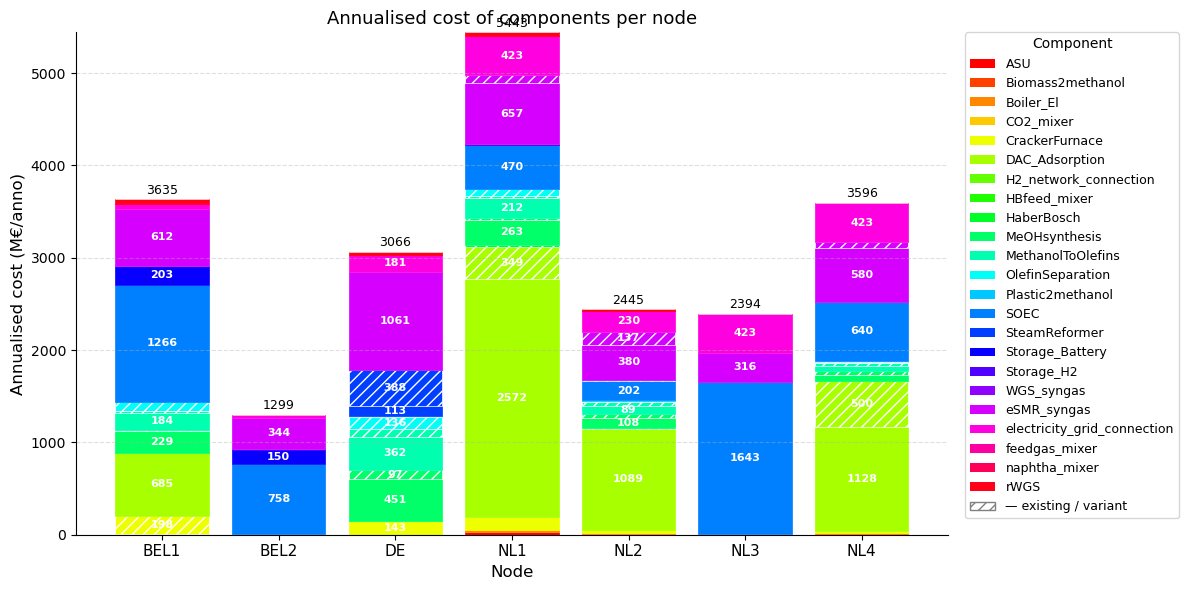

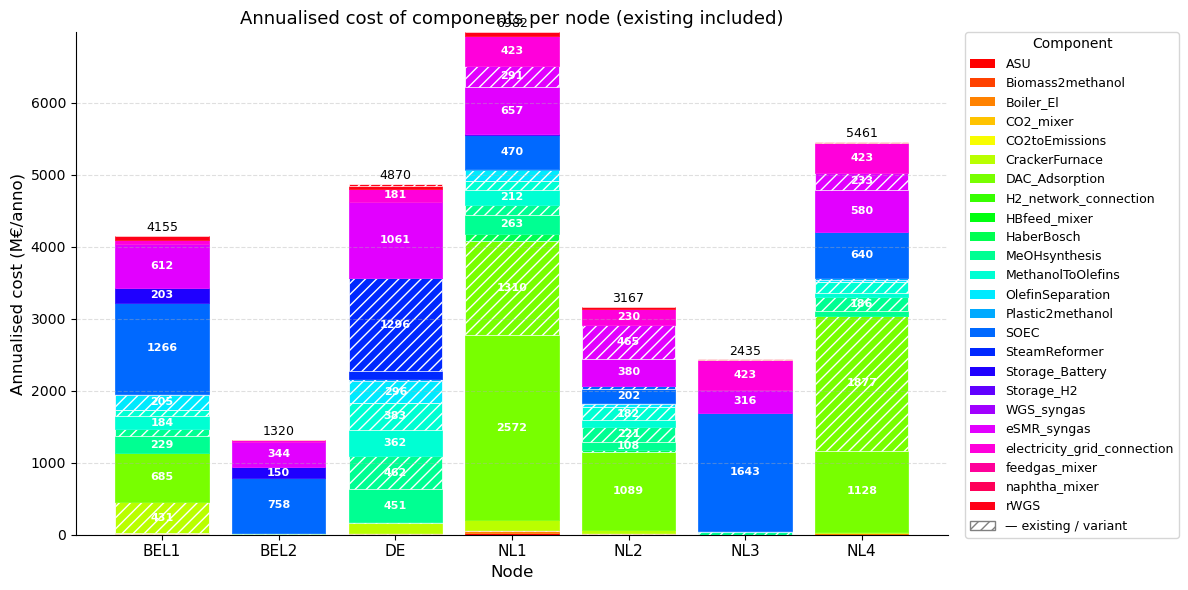

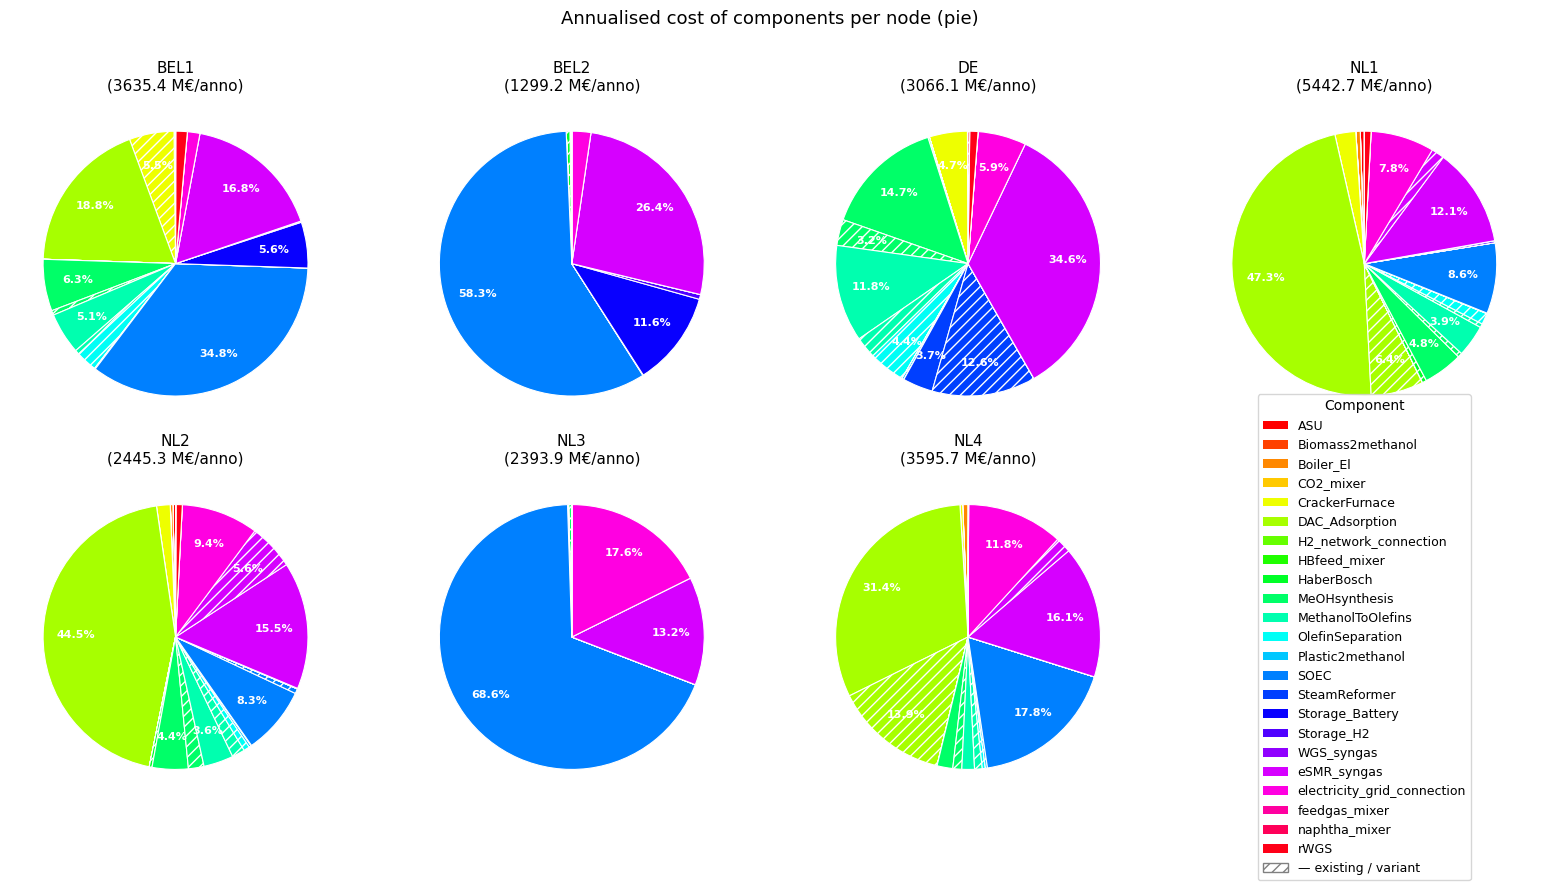

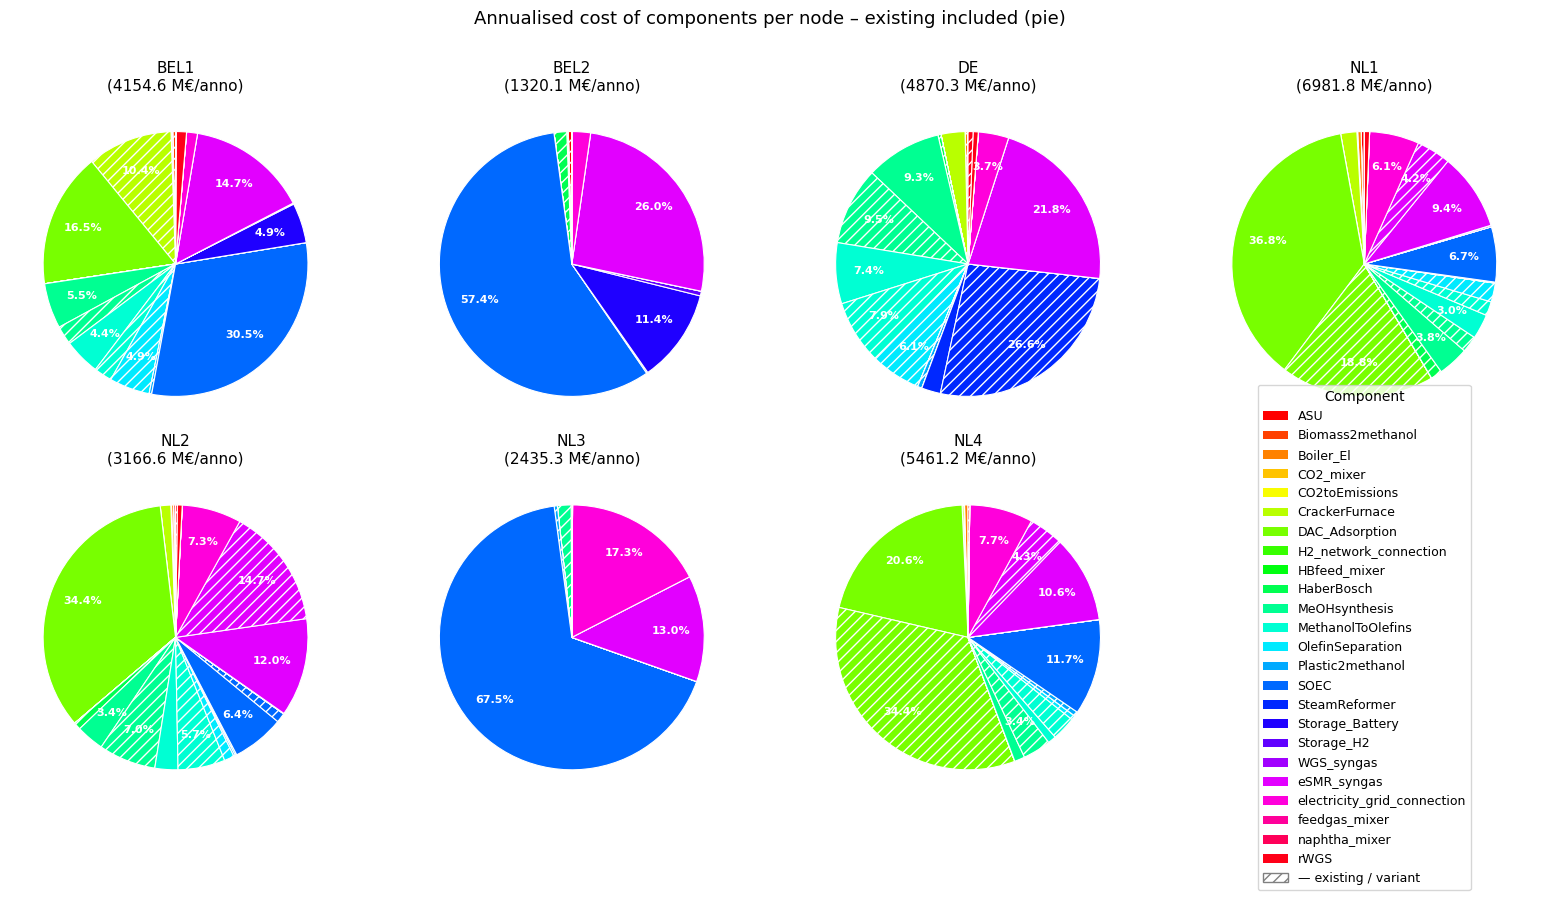

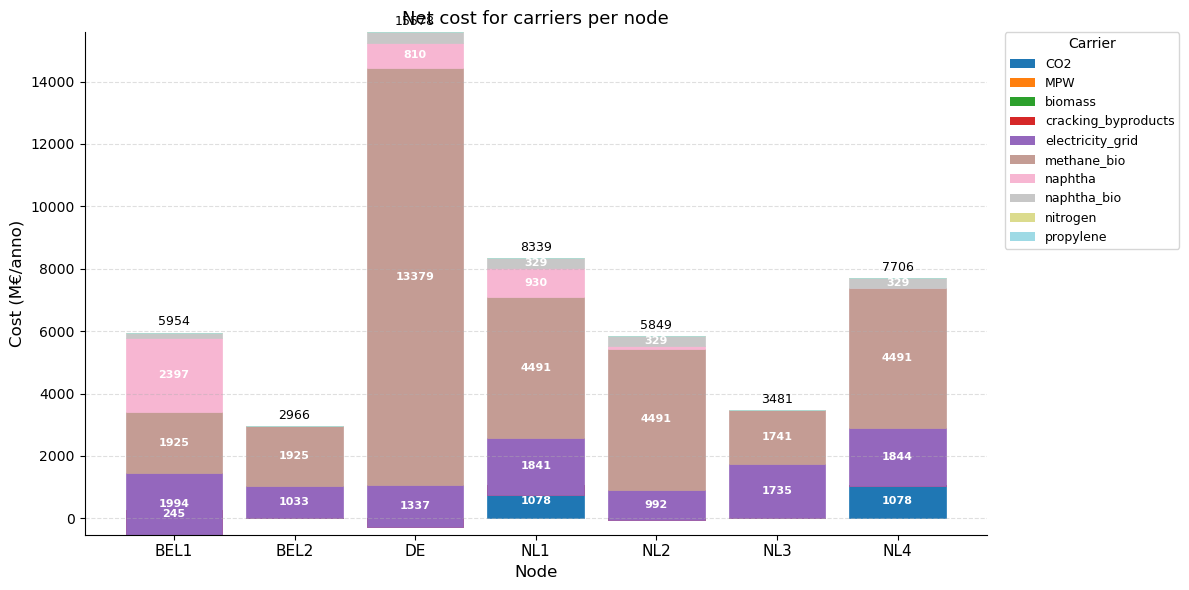

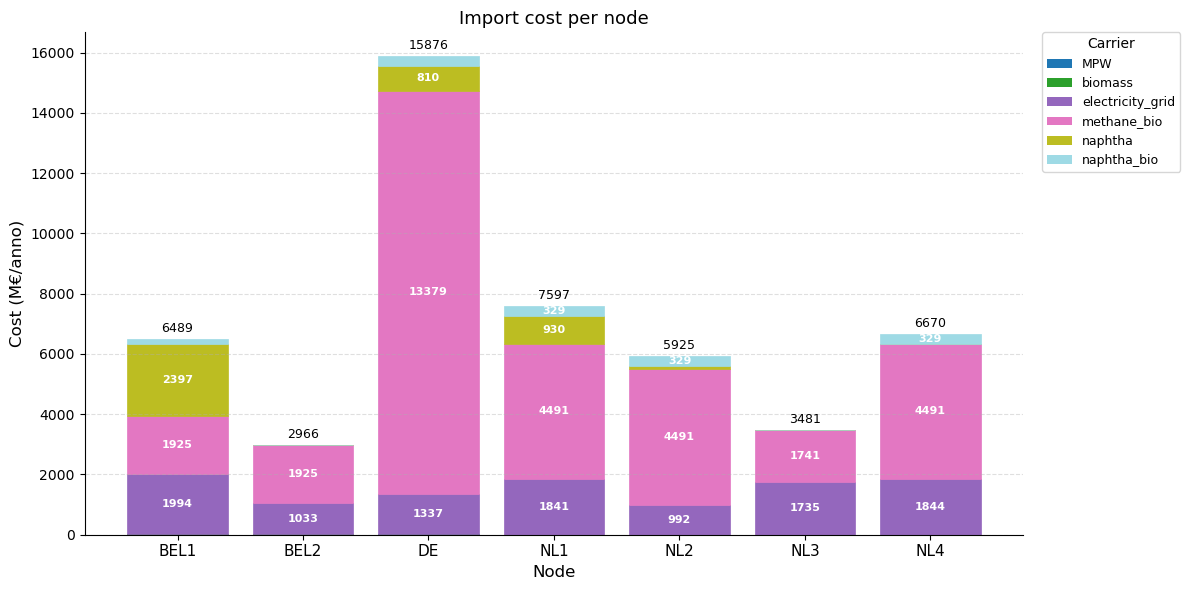

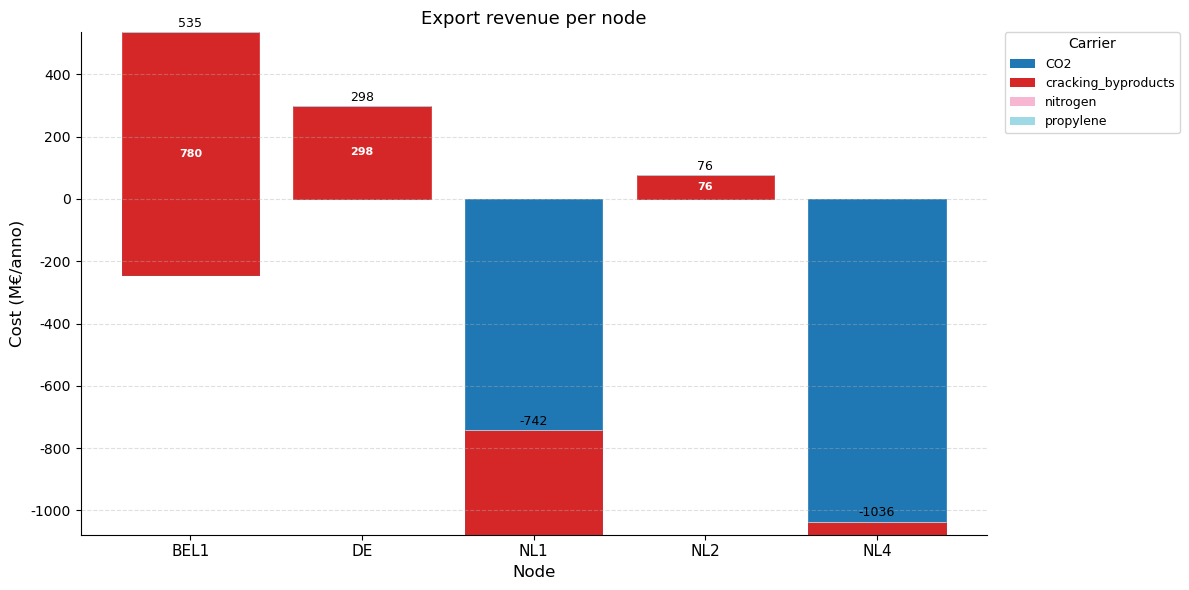

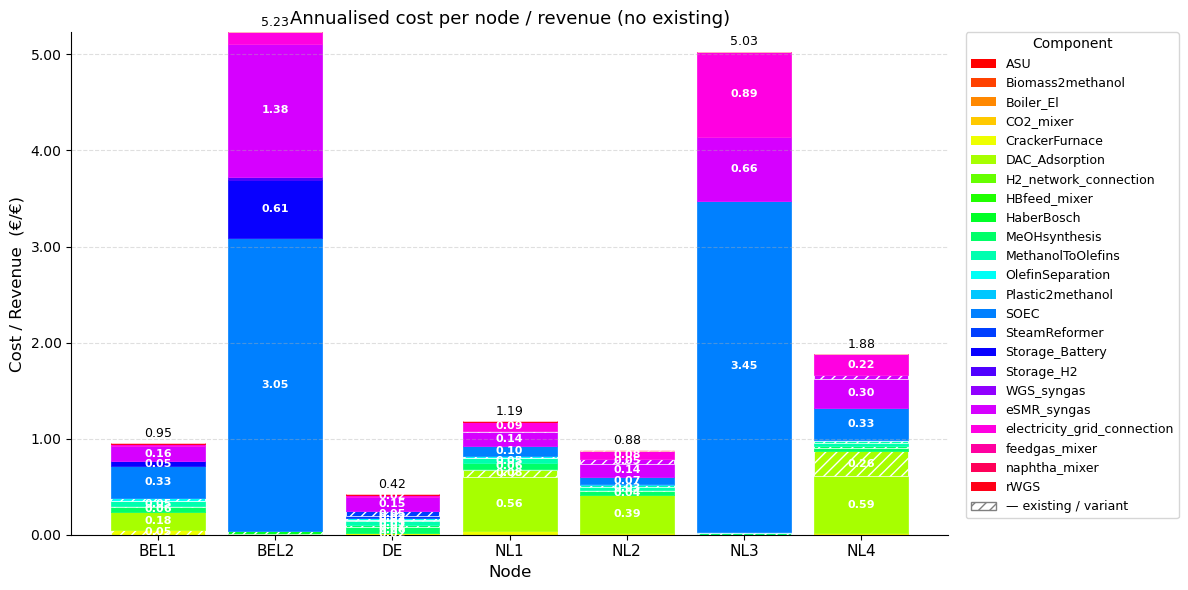

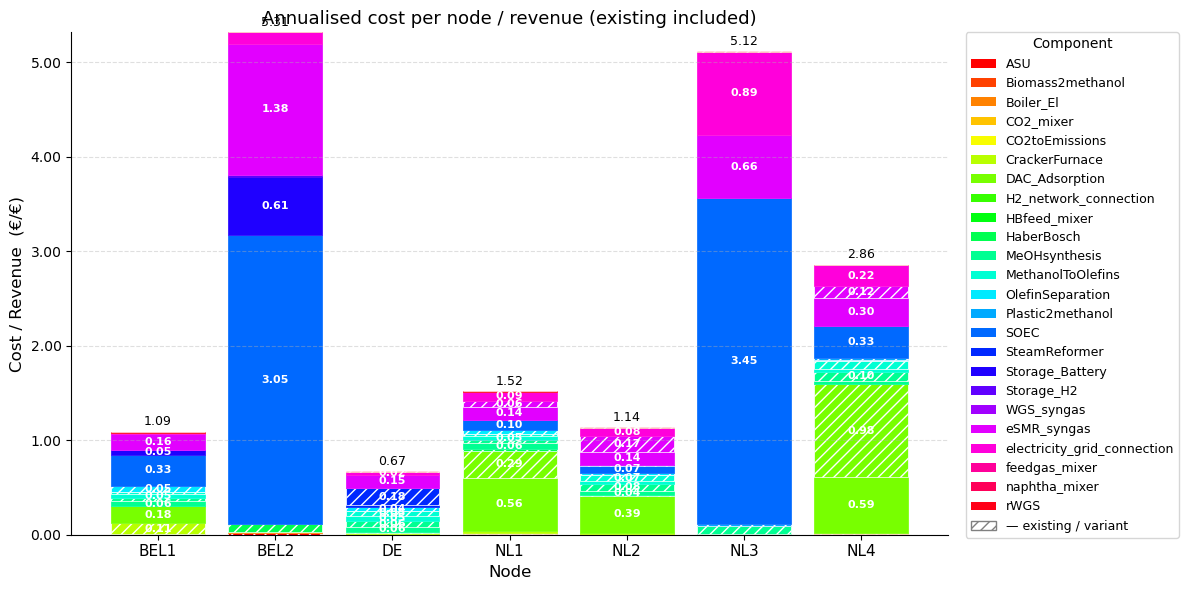

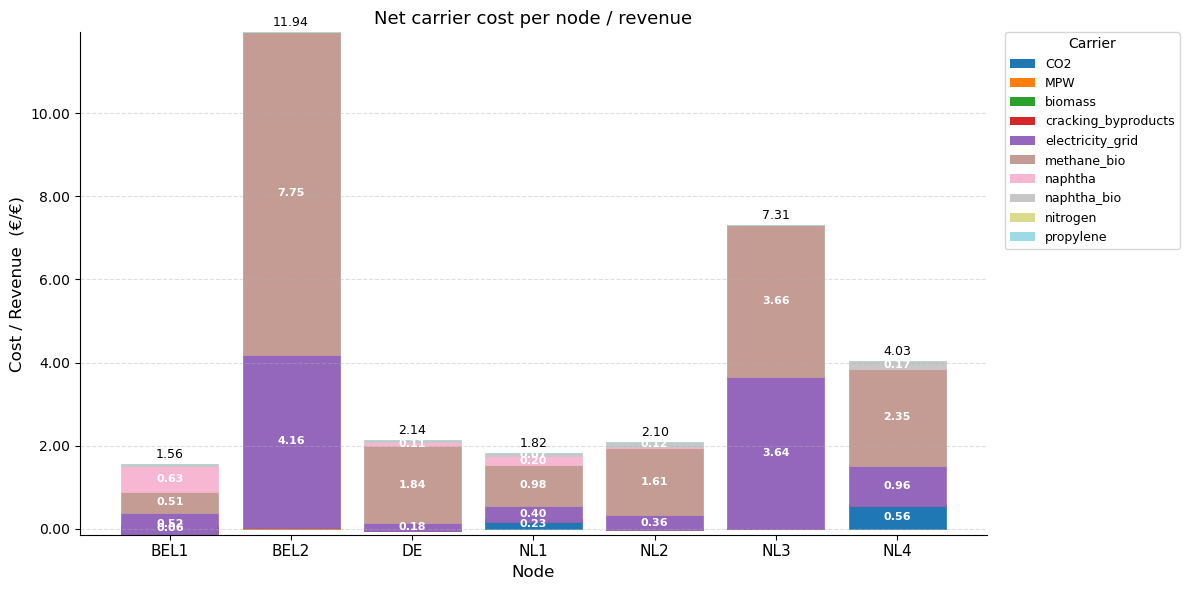

In [7]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors


# ─────────────────────────────────────────────
#  HDF5 helpers
# ─────────────────────────────────────────────

def _to_scalar(x):
    """HDF5 dataset -> python scalar, decodes bytes."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    return x


def _annualise(unit_capex: float, size: float,
               discount_rate: float, lifetime: int) -> float:
    """
    Evaluates annualised CAPEX for a component of given size, using the formula:
        CRF = r*(1+r)^n / ((1+r)^n - 1)
        annualized_capex = unit_capex * size * CRF
    where r = discount_rate, n = lifetime.
    """
    r, n = discount_rate, lifetime
    crf = r * (1 + r)**n / ((1 + r)**n - 1)
    return unit_capex * size * crf


def _find_json_recursive(technology_data_root: str | Path, tec_name: str) -> Path | None:
    """
    Searches recursively in technology_data_root for a file named '{tec_name}.json'.
    Returns the Path if found, else None. If multiple matches are found, a warning is printed and the first one is returned.
    """
    root = Path(technology_data_root)
    matches = list(root.rglob(f"{tec_name}.json"))
    if not matches:
        return None
    if len(matches) > 1:
        print(f"[Warning] Found {len(matches)} files for '{tec_name}', using the first: {matches[0]}")
    return matches[0]

def _aggregate_network_components(df: pd.DataFrame) -> pd.DataFrame:
    """
    Raggruppa i componenti il cui nome inizia con uno dei prefissi in
    _NETWORK_COMPONENT_PREFIXES seguito da '_qualcosa', rinominandoli
    al solo prefisso base. Il successivo pivot_table sommerà automaticamente
    le righe con lo stesso nome nodo+componente.
    """
    import re

    d = df.copy()
    patterns = [
        (re.compile(rf"^{re.escape(p)}_.+$"), p)
        for p in _NETWORK_COMPONENT_PREFIXES
    ]
    def _rename(name: str) -> str:
        for pat, base in patterns:
            if pat.match(name):
                return base
        return name
    d["component"] = d["component"].apply(_rename)
    return d


def create_base_df(h5_path: str | Path, year: str = "2022") -> pd.DataFrame:
    """Returns all (node, component) pairs under design/nodes/{year}."""
    h5_path = Path(h5_path)
    base = f"design/nodes/{year}"
    rows = []
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        for node in f[base].keys():
            for comp in f[base][node].keys():
                rows.append({"node": str(node), "component": str(comp)})
    return pd.DataFrame(rows)


def load_technologies_design_results(
    dataset_name: str, # e.g. 'capex_tot', 'opex_fixed', 'opex_variable'
    h5_path: str | Path,
    year: str = "2022",
    base_df: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Adds a column with dataset_name values to base_df."""
    h5_path = Path(h5_path)
    df = base_df.copy() if base_df is not None else pd.DataFrame()
    df[dataset_name] = np.nan
    base = f"design/nodes/{year}"
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        for node in f[base].keys():
            for comp in f[base][node].keys():
                ds_path = f"{base}/{node}/{comp}/{dataset_name}"
                if ds_path in f:
                    val = _to_scalar(f[ds_path][()])
                    mask = (df["node"] == str(node)) & (df["component"] == str(comp))
                    df.loc[mask, dataset_name] = float(val) if val is not None else np.nan
    return df

def load_existing_annualized_capex(
    h5_path: str | Path,
    technology_data_root: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """
    For each component with suffix '_existing' under design/nodes/{year}, reads its 'size' from the HDF5 and the economic parameters from the corresponding JSON in technology_data_root,
    then computes the annualized CAPEX using the _annualise() function.
    Returns a DataFrame with columns:
        node, component, size, unit_capex, discount_rate, lifetime, annualized_capex_existing
        where 'component' is the full name with '_existing' suffix, and 'annualized_capex_existing' is the computed annualized CAPEX for that component.
    """
    h5_path = Path(h5_path)
    base    = f"design/nodes/{year}"
    rows    = []

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")

        for node in f[base].keys():
            for comp in f[base][node].keys():
                if not comp.endswith("_existing"):
                    continue

                # ── size from the h5 ──────────────────────────────
                size_path = f"{base}/{node}/{comp}/size"
                if size_path not in f:
                    print(f"[Warning] 'size' not found for {node}/{comp}, skip.")
                    continue
                size = float(_to_scalar(f[size_path][()]))

                # ── json of the technology ─────────────────────
                tec_name = comp[: -len("_existing")]   # remove suffix to get technology name
                json_path = _find_json_recursive(technology_data_root, tec_name)
                if json_path is None:
                    print(f"[Warning] JSON not found for '{tec_name}', skip.")
                    continue

                with open(json_path, "r") as jf:
                    tec_data = json.load(jf)

                econ         = tec_data["Economics"]
                unit_capex   = float(econ["unit_capex"])
                discount_rate = float(econ["discount_rate"])
                lifetime     = int(econ["lifetime"])

                ann_capex = _annualise(unit_capex, size, discount_rate, lifetime)

                rows.append({
                    "node":                      str(node),
                    "component":                 str(comp),
                    "size":                      size,
                    "unit_capex":                unit_capex,
                    "discount_rate":             discount_rate,
                    "lifetime":                  lifetime,
                    "annualized_capex_existing": ann_capex,
                })

    return pd.DataFrame(rows)


def load_networks_design_results(
    dataset_name: str,
    h5_path: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """Reads design/networks/{year}/... and splits capex 50/50 between fromNode and toNode."""
    h5_path = Path(h5_path)
    base = f"design/networks/{year}"
    rows = []
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        for network in f[base].keys():
            for edge_id in f[base][network].keys():
                edge_path = f"{base}/{network}/{edge_id}"
                from_node = _to_scalar(f[f"{edge_path}/fromNode"][()]) if f"{edge_path}/fromNode" in f else None
                to_node   = _to_scalar(f[f"{edge_path}/toNode"][()]) if f"{edge_path}/toNode" in f else None
                val = _to_scalar(f[f"{edge_path}/{dataset_name}"][()]) if f"{edge_path}/{dataset_name}" in f else np.nan
                val = float(val) / 2 if val is not None else np.nan
                rows.append({"node": str(from_node), "component": str(network), dataset_name: val})
                rows.append({"node": str(to_node),   "component": str(network), dataset_name: val})

    df = pd.DataFrame(rows)
    df = df.groupby(["node", "component"], as_index=False)[dataset_name].sum()
    return df


# ─────────────────────────────────────────────
#  Annual cost: capex_tot + opex_fixed + opex_variable
# ─────────────────────────────────────────────

def compute_annual_cost(
    h5_path: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """
    For every (node, component) reads three datasets from design/nodes/{year}:
        capex_tot      — already annualised CAPEX  (€/year)
        opex_fixed     — fixed operating cost      (€/year)
        opex_variable  — variable operating cost   (€/year)

    Returns a DataFrame with columns:
        node, component, capex_tot, opex_fixed, opex_variable, annual_cost

    where annual_cost = capex_tot + opex_fixed + opex_variable.
    Rows where all three are zero or NaN are kept; filtering is left to the caller.
    """
    base = create_base_df(h5_path, year=year)
    for col in ("capex_tot", "opex_fixed", "opex_variable"):
        base = load_technologies_design_results(col, h5_path, year=year, base_df=base)

    base["annual_cost"] = (
        base["capex_tot"].fillna(0)
        + base["opex_fixed"].fillna(0)
        + base["opex_variable"].fillna(0)
    )
    return base

def compute_annual_cost_with_existing(
    h5_path: str | Path,
    technology_data_root: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """
    As compute_annual_cost, but for '_existing' technologies replaces capex_tot (which is 0 in the HDF5) with the annualized_capex computed from the JSON.
    Returns the same columns as compute_annual_cost:
        node, component, capex_tot, opex_fixed, opex_variable, annual_cost
    """
    df = compute_annual_cost(h5_path, year=year)

    existing_capex = load_existing_annualized_capex(h5_path, technology_data_root, year=year)

    if existing_capex.empty:
        return df

    # Merging and substitution of capex_tot for the _existing rows
    df = df.merge(
        existing_capex[["node", "component", "annualized_capex_existing"]],
        on=["node", "component"],
        how="left",
    )
    mask = df["annualized_capex_existing"].notna()
    df.loc[mask, "capex_tot"] = df.loc[mask, "annualized_capex_existing"]
    df["annual_cost"] = (
        df["capex_tot"].fillna(0)
        + df["opex_fixed"].fillna(0)
        + df["opex_variable"].fillna(0)
    )
    df = df.drop(columns=["annualized_capex_existing"])
    return df


# ─────────────────────────────────────────────
#  Import / Export cost loader
# ─────────────────────────────────────────────

def load_import_export_costs(
    h5_path: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """
    For every (node, carrier) pair computes the annual import and export costs
    using the k-means weighting factors stored in k_means_specs/{year}/factors.

    Annual cost formula (weighted sum over typical-day timesteps):
        import_cost  = sum_t( import[t]  * import_price[t]  * factor[t] )
        export_cost  = sum_t( export[t]  * export_price[t]  * factor[t] )
        net_cost     = import_cost - export_cost   (positive = net spend)

    Returns a DataFrame with columns:
        node, carrier, import_cost, export_cost, net_cost
    """
    h5_path = Path(h5_path)
    rows = []

    with h5py.File(h5_path, "r") as f:
        factors_path = f"k_means_specs/{year}/factors"
        if factors_path not in f:
            raise KeyError(f"Path '{factors_path}' not found in the file.")
        factors = np.array(f[factors_path], dtype=float)

        eb_base = f"operation/energy_balance/{year}"
        if eb_base not in f:
            raise KeyError(f"Path '{eb_base}' not found in the file.")

        for node in f[eb_base].keys():
            for carrier in f[eb_base][node].keys():
                carrier_path = f"{eb_base}/{node}/{carrier}"

                imp       = np.array(f[f"{carrier_path}/import"],       dtype=float)
                exp       = np.array(f[f"{carrier_path}/export"],       dtype=float)
                imp_price = np.array(f[f"{carrier_path}/import_price"], dtype=float)
                exp_price = np.array(f[f"{carrier_path}/export_price"], dtype=float)

                import_cost = float(np.sum(imp * imp_price * factors))
                export_cost = float(np.sum(exp * exp_price * factors))

                rows.append({
                    "node":        str(node),
                    "carrier":     str(carrier),
                    "import_cost": import_cost,
                    "export_cost": export_cost,
                    "net_cost":    import_cost - export_cost,
                })

    return pd.DataFrame(rows)


def revenues_from_chemicals(
    h5_path: str | Path,
    chemical_prices: dict[str, float],
    year: str = "2022",
) -> pd.DataFrame:
    """
    For each node, computes the annual revenue from chemical production.
 
    For each chemical in chemical_prices, reads the 'demand' array from
    operation/energy_balance/{year}/{node}/{chemical}/demand, weights it
    with the k-means factors (same approach as load_import_export_costs),
    and multiplies by the price in €/tonne.
 
    Parameters
    ----------
    h5_path : path to the HDF5 file
    chemical_prices : dict mapping chemical name -> price in €/tonne
                      e.g. {'ammonia': 578, 'methanol': 527, ...}
    year : scenario year (default "2022")
 
    Returns
    -------
    DataFrame with columns:
        node, <chemical_1>, <chemical_2>, ..., total_revenue
    where each chemical column is the annual revenue in € for that node.
    """
    h5_path = Path(h5_path)
    rows = []
 
    with h5py.File(h5_path, "r") as f:
        # Load k-means weighting factors (same as in load_import_export_costs)
        factors_path = f"k_means_specs/{year}/factors"
        if factors_path not in f:
            raise KeyError(f"Path '{factors_path}' not found in the file.")
        factors = np.array(f[factors_path], dtype=float)
 
        eb_base = f"operation/energy_balance/{year}"
        if eb_base not in f:
            raise KeyError(f"Path '{eb_base}' not found in the file.")
 
        for node in f[eb_base].keys():
            row = {"node": str(node)}
            for chemical, price in chemical_prices.items():
                demand_path = f"{eb_base}/{node}/{chemical}/demand"
                export_path = f"{eb_base}/{node}/{chemical}/export"
                if demand_path in f:
                    demand = np.array(f[demand_path], dtype=float)
                    # Weighted sum over typical-day timesteps, same as import/export
                else:
                    demand = np.zeros_like(factors)
                if export_path in f:
                    export = np.array(f[export_path], dtype=float)
                else:
                    export = np.zeros_like(factors)
                annual_production = float(np.sum(demand * factors) + np.sum(export * factors))
                row[chemical] = annual_production * price
            rows.append(row)
 
    df = pd.DataFrame(rows)
 
    # Total revenue per node (sum across all chemicals)
    chemical_cols = list(chemical_prices.keys())
    df["total_revenue"] = df[chemical_cols].sum(axis=1)
 
    return df


# ─────────────────────────────────────────────
#  Color + hatch palette
# ─────────────────────────────────────────────

_HATCH_PATTERN = "///"
_KNOWN_SUFFIXES = ["_existing", "_new", "_ccs"]
_NETWORK_COMPONENT_PREFIXES = [
    "H2_network_connection",
    "electricity_grid_connection",
]


def _strip_suffix(name: str) -> str:
    for suffix in _KNOWN_SUFFIXES:
        if name.endswith(suffix):
            return name[: -len(suffix)]
    return name


def _has_suffix(name: str) -> bool:
    return any(name.endswith(s) for s in _KNOWN_SUFFIXES)


def _build_palette(
    components: list[str],
    cmap_name: str = "tab20",
) -> tuple[dict[str, str], dict[str, str]]:
    """
    Returns (color_map, hatch_map) keyed on component name.
    Colors assigned to base names; variants share the color but get hatch.
    """
    seen: dict[str, None] = {}
    for comp in components:
        seen[_strip_suffix(comp)] = None
    base_names = list(seen.keys())

    n = len(base_names)
    cmap   = plt.get_cmap(cmap_name) if n <= 20 else plt.get_cmap("hsv")
    colors = [mcolors.to_hex(cmap(i / max(n - 1, 1))) for i in range(n)]

    base_color = dict(zip(base_names, colors))
    color_map  = {comp: base_color[_strip_suffix(comp)] for comp in components}
    hatch_map  = {comp: (_HATCH_PATTERN if _has_suffix(comp) else "") for comp in components}
    return color_map, hatch_map


def _build_simple_palette(items: list[str], cmap_name: str = "tab20") -> dict[str, str]:
    n = len(items)
    cmap   = plt.get_cmap(cmap_name) if n <= 20 else plt.get_cmap("hsv")
    colors = [mcolors.to_hex(cmap(i / max(n - 1, 1))) for i in range(n)]
    return dict(zip(items, colors))


# ─────────────────────────────────────────────
#  Generic stacked bar plot
# ─────────────────────────────────────────────

def _plot_stacked(
    pivot: pd.DataFrame,
    color_map: dict[str, str],
    hatch_map: dict[str, str] | None,
    ax: plt.Axes,
    min_fraction_label: float,
    value_decimals: int = 0,
):
    hatch_map = hatch_map or {c: "" for c in pivot.columns}
    x       = np.arange(len(pivot.index))
    bottoms = np.zeros(len(pivot.index))

    for comp in pivot.columns:
        values = pivot[comp].values
        bars   = ax.bar(
            x, values, bottom=bottoms,
            color=color_map[comp],
            hatch=hatch_map[comp],
            edgecolor="white" if hatch_map[comp] else color_map[comp],
            linewidth=0.5,
            label=comp,
        )
        node_totals = pivot.sum(axis=1).values
        for i, (bar, v) in enumerate(zip(bars, values)):
            if node_totals[i] > 0 and v / node_totals[i] >= min_fraction_label:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottoms[i] + v / 2,
                    f"{v:.{value_decimals}f}",
                    ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold",
                )
        bottoms += values

    for i, total in enumerate(pivot.sum(axis=1).values):
        ax.text(
            x[i], total + 0.01 * (pivot.values.max() or 1),
            f"{total:.{value_decimals}f}",
            ha="center", va="bottom", fontsize=9,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=0, fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{value_decimals}f}"))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)


# ─────────────────────────────────────────────
#  Plot: annualised cost per node and component
# ─────────────────────────────────────────────

def plot_stacked_annual_cost_by_node(
    df: pd.DataFrame,
    cost_col: str = "annual_cost",
    node_order: list[str] | None = None,
    top_n_components: int | None = None,
    drop_zeros: bool = True,
    scale: float = 1e6,
    scale_label: str = "M€/anno",
    cmap_name: str = "tab20",
    title: str = "Annualised cost of components per node",
    figsize: tuple[int, int] = (12, 6),
    min_fraction_label: float = 0.03,
):
    """
    Stacked bar chart: x=node, stack=component, y=annual_cost.
    annual_cost = capex_tot + opex_fixed + opex_variable (all already in €/year).
    Components with a known suffix (_existing, _new, …) share the base color
    but are drawn with diagonal hatch stripes.
    """
    d = df.copy()
    d = _aggregate_network_components(d)
    d[cost_col] = pd.to_numeric(d[cost_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[cost_col] > 0]
    d[cost_col] /= scale

    pivot = d.pivot_table(index="node", columns="component",
                          values=cost_col, aggfunc="sum", fill_value=0.0)

    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()

    if top_n_components is not None:
        base_totals = (
            pivot.rename(columns=_strip_suffix).T.groupby(level=0).sum().T
            .sum(axis=0).sort_values(ascending=False)
        )
        keep_bases = set(base_totals.index[:top_n_components])
        keep_cols  = [c for c in pivot.columns if _strip_suffix(c) in keep_bases]
        other      = pivot[[c for c in pivot.columns if c not in keep_cols]].sum(axis=1)
        pivot      = pivot[keep_cols].copy()
        if (other > 0).any():
            pivot["Other"] = other

    components           = list(pivot.columns)
    color_map, hatch_map = _build_palette(components, cmap_name)

    fig, ax = plt.subplots(figsize=figsize)
    _plot_stacked(pivot, color_map, hatch_map, ax, min_fraction_label)

    ax.set_ylabel(f"Annualised cost ({scale_label})", fontsize=12)
    ax.set_xlabel("Node", fontsize=12)
    ax.set_title(title, fontsize=13)

    legend_handles = []
    seen_bases: set[str] = set()
    for comp in components:
        base = _strip_suffix(comp)
        if base not in seen_bases:
            seen_bases.add(base)
            legend_handles.append(mpatches.Patch(facecolor=color_map[comp], label=base))
    if any(v for v in hatch_map.values()):
        legend_handles.append(
            mpatches.Patch(facecolor="white", edgecolor="gray",
                           hatch=_HATCH_PATTERN, label="— existing / variant")
        )
    ax.legend(handles=legend_handles, title="Component",
              bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)

    plt.tight_layout()
    # plt.savefig("annual_cost_stacked.png", dpi=150, bbox_inches="tight")
    plt.show()

def plot_pie_annual_cost_by_node(
    df: pd.DataFrame,
    cost_col: str = "annual_cost",
    node_order: list[str] | None = None,
    top_n_components: int | None = None,
    drop_zeros: bool = True,
    scale: float = 1e6,
    scale_label: str = "M€/anno",
    cmap_name: str = "tab20",
    title: str = "Annualised cost of components per node",
    figsize: tuple[int, int] | None = None,
    min_fraction_label: float = 0.03,
):
    """
    Grid of pie charts: one pie per node, slices = components.
    Uses the same color/hatch palette as plot_stacked_annual_cost_by_node.
    """
    d = df.copy()
    d = _aggregate_network_components(d)
    d[cost_col] = pd.to_numeric(d[cost_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[cost_col] > 0]
    d[cost_col] /= scale

    pivot = d.pivot_table(
        index="node", columns="component",
        values=cost_col, aggfunc="sum", fill_value=0.0,
    )

    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()

    if top_n_components is not None:
        base_totals = (
            pivot.rename(columns=_strip_suffix).T.groupby(level=0).sum().T
            .sum(axis=0).sort_values(ascending=False)
        )
        keep_bases = set(base_totals.index[:top_n_components])
        keep_cols  = [c for c in pivot.columns if _strip_suffix(c) in keep_bases]
        other      = pivot[[c for c in pivot.columns if c not in keep_cols]].sum(axis=1)
        pivot      = pivot[keep_cols].copy()
        if (other > 0).any():
            pivot["Other"] = other

    components           = list(pivot.columns)
    color_map, hatch_map = _build_palette(components, cmap_name)
    colors               = [color_map[c] for c in components]
    hatches              = [hatch_map[c] for c in components]

    nodes   = list(pivot.index)
    n_nodes = len(nodes)

    # Layout: try to make a roughly square grid
    n_cols = min(n_nodes, 4)
    n_rows = int(np.ceil(n_nodes / n_cols))

    if figsize is None:
        figsize = (n_cols * 4, n_rows * 4)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes_flat = np.array(axes).flatten()

    for ax, node in zip(axes_flat, nodes):
        values = pivot.loc[node].values
        total  = values.sum()

        # Only show label on slices above min_fraction_label
        def _autopct(pct):
            return f"{pct:.1f}%" if pct / 100 >= min_fraction_label else ""

        wedges, texts, autotexts = ax.pie(
            values,
            colors=colors,
            autopct=_autopct,
            startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 0.8},
            pctdistance=0.75,
        )
        # Apply hatch patterns to wedges
        for wedge, hatch in zip(wedges, hatches):
            wedge.set_hatch(hatch)

        for autotext in autotexts:
            autotext.set_fontsize(8)
            autotext.set_color("white")
            autotext.set_fontweight("bold")

        ax.set_title(f"{node}\n({total:.1f} {scale_label})", fontsize=11)

    # Hide unused axes
    for ax in axes_flat[n_nodes:]:
        ax.set_visible(False)

    # Shared legend (same logic as the bar chart)
    legend_handles = []
    seen_bases: set[str] = set()
    for comp in components:
        base = _strip_suffix(comp)
        if base not in seen_bases:
            seen_bases.add(base)
            legend_handles.append(mpatches.Patch(facecolor=color_map[comp], label=base))
    if any(v for v in hatch_map.values()):
        legend_handles.append(
            mpatches.Patch(facecolor="white", edgecolor="gray",
                           hatch=_HATCH_PATTERN, label="— existing / variant")
        )

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()

    # Metti la legenda nell'ultimo axes vuoto, se esiste
    empty_axes = axes_flat[n_nodes:]
    if len(empty_axes) > 0:
        legend_ax = empty_axes[-1]
        legend_ax.set_visible(True)
        legend_ax.axis("off")
        legend_ax.legend(
            handles=legend_handles,
            title="Component",
            loc="center",
            fontsize=9,
            frameon=True,
        )
    else:
        # Fallback: legenda fuori dalla figura in basso
        fig.legend(
            handles=legend_handles,
            title="Component",
            loc="lower center",
            ncol=min(len(legend_handles), 5),
            fontsize=9,
            bbox_to_anchor=(0.5, -0.02),
        )

    plt.show()


# ─────────────────────────────────────────────
#  Plot: costs for import/export by node and carrier
# ─────────────────────────────────────────────

def plot_stacked_import_export_by_node(
    df: pd.DataFrame,
    cost_col: str = "net_cost",
    node_order: list[str] | None = None,
    top_n_carriers: int | None = None,
    drop_zeros: bool = True,
    scale: float = 1e6,
    scale_label: str = "M€/anno",
    cmap_name: str = "tab20",
    title: str = "Import/export costs by node",
    figsize: tuple[int, int] = (12, 6),
    min_fraction_label: float = 0.03,
):
    """
    Stacked bar chart of import/export costs by node and carrier.
    cost_col: 'import_cost', 'export_cost', or 'net_cost'.
    """
    d = df.copy()
    d[cost_col] = pd.to_numeric(d[cost_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[cost_col].abs() > 0]
    d[cost_col] /= scale

    pivot = d.pivot_table(index="node", columns="carrier",
                          values=cost_col, aggfunc="sum", fill_value=0.0)

    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()

    if top_n_carriers is not None and pivot.shape[1] > top_n_carriers:
        totals = pivot.abs().sum(axis=0).sort_values(ascending=False)
        keep   = totals.index[:top_n_carriers].tolist()
        other  = pivot.drop(columns=keep).sum(axis=1)
        pivot  = pivot[keep].copy()
        if (other.abs() > 0).any():
            pivot["Other"] = other

    carriers  = list(pivot.columns)
    color_map = _build_simple_palette(carriers, cmap_name)
    hatch_map = {c: "" for c in carriers}

    fig, ax = plt.subplots(figsize=figsize)
    _plot_stacked(pivot, color_map, hatch_map, ax, min_fraction_label)

    ax.set_ylabel(f"Cost ({scale_label})", fontsize=12)
    ax.set_xlabel("Node", fontsize=12)
    ax.set_title(title, fontsize=13)

    legend_handles = [mpatches.Patch(facecolor=color_map[c], label=c) for c in carriers]
    ax.legend(handles=legend_handles, title="Carrier",
              bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)

    plt.tight_layout()
    # plt.savefig("import_export_costs.png", dpi=150, bbox_inches="tight")
    plt.show()


# ─────────────────────────────────────────────
#  Normalised stacked bar plots
# ─────────────────────────────────────────────
 
def plot_stacked_annual_cost_normalised(
    cost_df: pd.DataFrame,
    revenue_df: pd.DataFrame,
    cost_col: str = "annual_cost",
    node_order: list[str] | None = None,
    top_n_components: int | None = None,
    drop_zeros: bool = True,
    cmap_name: str = "tab20",
    title: str = "Annualised cost per node (normalised by revenue)",
    figsize: tuple[int, int] = (12, 6),
    min_fraction_label: float = 0.03,
    output_filename: str = "annual_cost_normalised.png",
):
    """
    Same as plot_stacked_annual_cost_by_node, but each cost value is divided
    by the total_revenue of that node.  Y-axis is therefore dimensionless
    (cost / revenue, i.e. €/€).
 
    Parameters
    ----------
    cost_df    : output of compute_annual_cost or compute_annual_cost_with_existing
    revenue_df : output of revenues_from_chemicals  (must have 'node' and 'total_revenue')
    All other parameters: same meaning as in plot_stacked_annual_cost_by_node.
    """
    d = cost_df.copy()
    d = _aggregate_network_components(d)
    d[cost_col] = pd.to_numeric(d[cost_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[cost_col] > 0]
 
    # Build revenue map: node -> total_revenue
    rev_map = revenue_df.set_index("node")["total_revenue"].to_dict()
 
    # Divide each cost by the revenue of its node (skip nodes with zero/missing revenue)
    def _normalise(row):
        rev = rev_map.get(row["node"], 0.0)
        if rev > 0:
            return row[cost_col] / rev
        return np.nan
 
    d["cost_normalised"] = d.apply(_normalise, axis=1)
    d = d.dropna(subset=["cost_normalised"])
 
    pivot = d.pivot_table(
        index="node", columns="component",
        values="cost_normalised", aggfunc="sum", fill_value=0.0,
    )
 
    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()
 
    if top_n_components is not None:
        base_totals = (
            pivot.rename(columns=_strip_suffix).T.groupby(level=0).sum().T
            .sum(axis=0).sort_values(ascending=False)
        )
        keep_bases = set(base_totals.index[:top_n_components])
        keep_cols  = [c for c in pivot.columns if _strip_suffix(c) in keep_bases]
        other      = pivot[[c for c in pivot.columns if c not in keep_cols]].sum(axis=1)
        pivot      = pivot[keep_cols].copy()
        if (other > 0).any():
            pivot["Other"] = other
 
    components           = list(pivot.columns)
    color_map, hatch_map = _build_palette(components, cmap_name)
 
    fig, ax = plt.subplots(figsize=figsize)
    _plot_stacked(pivot, color_map, hatch_map, ax, min_fraction_label, value_decimals=2)
 
    ax.set_ylabel("Cost / Revenue  (€/€)", fontsize=12)
    ax.set_xlabel("Node", fontsize=12)
    ax.set_title(title, fontsize=13)
 
    legend_handles = []
    seen_bases: set[str] = set()
    for comp in components:
        base = _strip_suffix(comp)
        if base not in seen_bases:
            seen_bases.add(base)
            legend_handles.append(mpatches.Patch(facecolor=color_map[comp], label=base))
    if any(v for v in hatch_map.values()):
        legend_handles.append(
            mpatches.Patch(facecolor="white", edgecolor="gray",
                           hatch=_HATCH_PATTERN, label="— existing / variant")
        )
    ax.legend(handles=legend_handles, title="Component",
              bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)
 
    plt.tight_layout()
    # plt.savefig(output_filename, dpi=150, bbox_inches="tight")
    plt.show()
 
 
def plot_stacked_import_export_normalised(
    ie_df: pd.DataFrame,
    revenue_df: pd.DataFrame,
    cost_col: str = "net_cost",
    node_order: list[str] | None = None,
    top_n_carriers: int | None = None,
    drop_zeros: bool = True,
    cmap_name: str = "tab20",
    title: str = "Import/export costs per node (normalised by revenue)",
    figsize: tuple[int, int] = (12, 6),
    min_fraction_label: float = 0.03,
    output_filename: str = "import_export_normalised.png",
):
    """
    Same as plot_stacked_import_export_by_node, but each cost value is divided
    by the total_revenue of that node.
 
    Parameters
    ----------
    ie_df      : output of load_import_export_costs
    revenue_df : output of revenues_from_chemicals  (must have 'node' and 'total_revenue')
    All other parameters: same meaning as in plot_stacked_import_export_by_node.
    """
    d = ie_df.copy()
    d[cost_col] = pd.to_numeric(d[cost_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[cost_col].abs() > 0]
 
    # Build revenue map: node -> total_revenue
    rev_map = revenue_df.set_index("node")["total_revenue"].to_dict()
 
    def _normalise(row):
        rev = rev_map.get(row["node"], 0.0)
        if rev > 0:
            return row[cost_col] / rev
        return np.nan
 
    d["cost_normalised"] = d.apply(_normalise, axis=1)
    d = d.dropna(subset=["cost_normalised"])
 
    pivot = d.pivot_table(
        index="node", columns="carrier",
        values="cost_normalised", aggfunc="sum", fill_value=0.0,
    )
 
    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()
 
    if top_n_carriers is not None and pivot.shape[1] > top_n_carriers:
        totals = pivot.abs().sum(axis=0).sort_values(ascending=False)
        keep   = totals.index[:top_n_carriers].tolist()
        other  = pivot.drop(columns=keep).sum(axis=1)
        pivot  = pivot[keep].copy()
        if (other.abs() > 0).any():
            pivot["Other"] = other
 
    carriers  = list(pivot.columns)
    color_map = _build_simple_palette(carriers, cmap_name)
    hatch_map = {c: "" for c in carriers}
 
    fig, ax = plt.subplots(figsize=figsize)
    _plot_stacked(pivot, color_map, hatch_map, ax, min_fraction_label, value_decimals=2)
 
    ax.set_ylabel("Cost / Revenue  (€/€)", fontsize=12)
    ax.set_xlabel("Node", fontsize=12)
    ax.set_title(title, fontsize=13)
 
    legend_handles = [mpatches.Patch(facecolor=color_map[c], label=c) for c in carriers]
    ax.legend(handles=legend_handles, title="Carrier",
              bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)
 
    plt.tight_layout()
    # plt.savefig(output_filename, dpi=150, bbox_inches="tight")
    plt.show()


# ─────────────────────────────────────────────
#  Main
# ─────────────────────────────────────────────

if __name__ == "__main__":
    h5_path               = Path(r"output\base_case_5_dd\2050\optimization_results.h5")
    technology_data_root  = Path(r"adopt_net0\database\templates\technology_data")
    year                  = "2022"
    node_order            = ["BEL1", "BEL2", "DE", "NL1", "NL2", "NL3", "NL4"]

    chemicals_prices = {
        'ammonia': 621, # €/tonne, source: https://www.imarcgroup.com/ammonia-pricing-report
        'methanol': 560, # €/tonne, source: https://www.imarcgroup.com/methanol-pricing-report
        'ethylene': 1028, # €/tonne, source: https://www.imarcgroup.com/ethylene-pricing-report
        'propylene': 960, # €/tonne, source: https://www.imarcgroup.com/propylene-pricing-report
    }

    revenue_df = revenues_from_chemicals(h5_path, chemical_prices=chemicals_prices, year=year)

    # ── Plot 1: annualised cost per node and component (only optimised capex, existing = 0) ──
    cost_df = compute_annual_cost(h5_path, year=year)
    plot_stacked_annual_cost_by_node(
        cost_df,
        cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost of components per node",
        scale=1e6, scale_label="M€/anno",
    )

    # ── Plot 2: as plot 1, but with annualised CAPEX for existing technologies ──
    cost_df_with_existing = compute_annual_cost_with_existing(
        h5_path, technology_data_root, year=year
    )
    plot_stacked_annual_cost_by_node(
        cost_df_with_existing,
        cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost of components per node (existing included)",
        scale=1e6, scale_label="M€/anno",
    )

    # ── Plot 1b: pie chart versione del Plot 1 ──────────────────────────────
    plot_pie_annual_cost_by_node(
        cost_df,
        cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost of components per node (pie)",
        scale=1e6, scale_label="M€/anno",
    )

    # ── Plot 2b: pie chart versione del Plot 2 (con existing) ───────────────
    plot_pie_annual_cost_by_node(
        cost_df_with_existing,
        cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost of components per node – existing included (pie)",
        scale=1e6, scale_label="M€/anno",
    )

    # ── Import/export plots ──────────────────────────────────────────────────────
    ie_costs = load_import_export_costs(h5_path, year=year)
    plot_stacked_import_export_by_node(
        ie_costs, cost_col="net_cost",
        node_order=node_order,
        title="Net cost for carriers per node",
        scale=1e6, scale_label="M€/anno",
    )
    plot_stacked_import_export_by_node(
        ie_costs, cost_col="import_cost",
        node_order=node_order,
        title="Import cost per node",
        scale=1e6, scale_label="M€/anno",
    )
    plot_stacked_import_export_by_node(
        ie_costs, cost_col="export_cost",
        node_order=node_order,
        title="Export revenue per node",
        scale=1e6, scale_label="M€/anno",
    )

    # Plot 4: costo annualizzato normalizzato (senza existing)
    plot_stacked_annual_cost_normalised(
        cost_df, revenue_df, cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost per node / revenue (no existing)",
        output_filename="annual_cost_normalised.png",
    )

    # Plot 5: costo annualizzato normalizzato (con existing)
    plot_stacked_annual_cost_normalised(
        cost_df_with_existing, revenue_df, cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost per node / revenue (existing included)",
        output_filename="annual_cost_with_existing_normalised.png",
    )

    # Plot 6: import/export normalizzato
    plot_stacked_import_export_normalised(
        ie_costs, revenue_df, cost_col="net_cost",
        node_order=node_order,
        title="Net carrier cost per node / revenue",
        output_filename="import_export_normalised.png",
    )

Map for network operation

C:\Users\alessandro.magnino\AppData\Local\Temp\ipykernel_20700\3278493013.py:208: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap  = mcm.get_cmap(cmap_name)


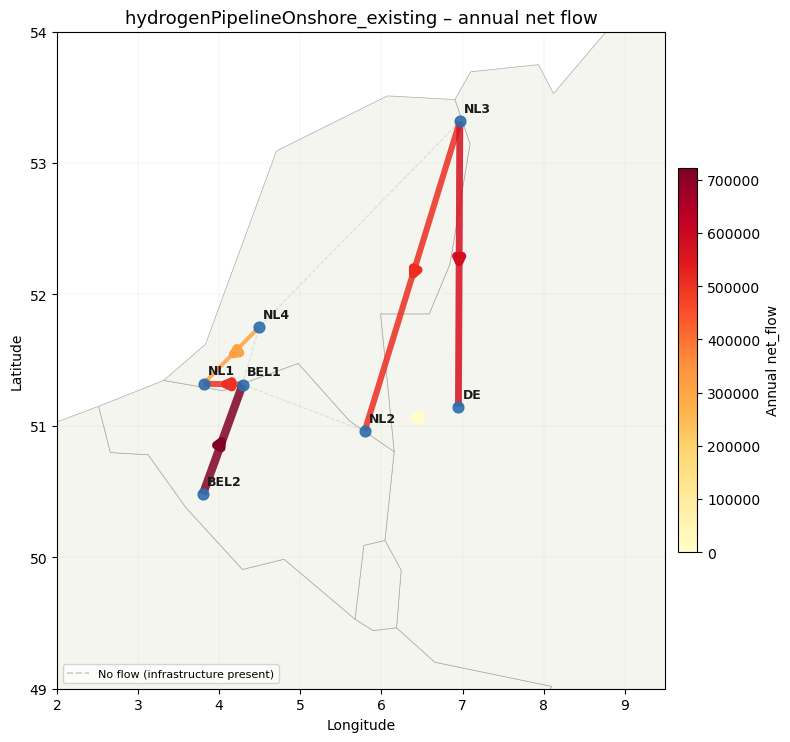

ValueError: Cannot set a DataFrame without columns to the column pair

In [3]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
from matplotlib.lines import Line2D
from shapely.geometry import LineString


# ─────────────────────────────────────────────
#  HDF5 helper
# ─────────────────────────────────────────────

def _to_scalar(x):
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    return x


# ─────────────────────────────────────────────
#  Data loading
# ─────────────────────────────────────────────

def read_network_flows(
    h5_path: str | Path,
    year: str = "2022",
    network: str = "hydrogenPipelineOnshore_existing",
) -> pd.DataFrame:
    """
    Reads all edges of a network and computes the **annual flow** using
    k-means weighting factors:

        annual_flow(edge) = sum_t( flow[t] * factor[t] )

    For each undirected pair (A, B) the net flow and dominant direction are
    computed:
        net_flow  = annual_flow(A→B) − annual_flow(B→A)
        direction : A→B if net_flow > 0, else B→A
        |net_flow|: used for visual scaling

    Returns a DataFrame with columns:
        edge_id, fromNode, toNode,          ← original directed edge
        annual_flow,                         ← weighted annual flow (directed)
        pair, net_from, net_to, net_flow     ← undirected pair with net direction
    """
    h5_path = Path(h5_path)
    base_design = f"design/networks/{year}/{network}"
    base_op     = f"operation/networks/{year}/{network}"

    with h5py.File(h5_path, "r") as f:
        if base_design not in f:
            raise KeyError(f"'{base_design}' not found in HDF5.")

        factors = np.array(f[f"k_means_specs/{year}/factors"], dtype=float)

        rows = []
        for eid in f[base_design].keys():
            from_node = _to_scalar(f[f"{base_design}/{eid}/fromNode"][()])
            to_node   = _to_scalar(f[f"{base_design}/{eid}/toNode"][()])

            flow_path = f"{base_op}/{eid}/flow"
            if flow_path in f:
                flow = np.array(f[flow_path], dtype=float)
                annual = float(np.sum(flow * factors))
            else:
                annual = 0.0

            rows.append({
                "edge_id":    eid,
                "fromNode":   str(from_node),
                "toNode":     str(to_node),
                "annual_flow": annual,
            })

    df = pd.DataFrame(rows)

    # ── Net flow per undirected pair ──────────────────────────────────────
    # canonical pair key: always sort nodes alphabetically
    df["pair"] = df.apply(
        lambda r: tuple(sorted([r["fromNode"], r["toNode"]])), axis=1
    )

    net_rows = []
    for pair, grp in df.groupby("pair"):
        a, b = pair
        flow_ab = grp.loc[grp["fromNode"] == a, "annual_flow"].sum()
        flow_ba = grp.loc[grp["fromNode"] == b, "annual_flow"].sum()
        net = flow_ab - flow_ba
        net_rows.append({
            "pair":     pair,
            "net_from": a if net >= 0 else b,
            "net_to":   b if net >= 0 else a,
            "net_flow": abs(net),
        })

    net_df = pd.DataFrame(net_rows)
    df = df.merge(net_df, on="pair", how="left")
    return df


def attach_geometry(
    edges_df: pd.DataFrame,
    nodes_csv: str | Path,
) -> pd.DataFrame:
    """
    Adds from/to coordinates from a CSV with columns: cluster, latitude, longitude.
    Uses net_from / net_to so geometry already reflects the net flow direction.
    """
    nodes  = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)
    coords = nodes.set_index("cluster")[["latitude", "longitude"]]

    out = edges_df.copy()
    out["from_lat"] = out["net_from"].map(coords["latitude"])
    out["from_lon"] = out["net_from"].map(coords["longitude"])
    out["to_lat"]   = out["net_to"].map(coords["latitude"])
    out["to_lon"]   = out["net_to"].map(coords["longitude"])
    return out


# ─────────────────────────────────────────────
#  Map
# ─────────────────────────────────────────────

def plot_network_map(
    edges_df: pd.DataFrame,
    nodes_csv: str | Path,
    flow_col: str = "net_flow",
    bbox: tuple[float, float, float, float] = (2.0, 49.0, 9.5, 54.0),
    min_lw: float = 0.5,
    max_lw: float = 6.0,
    cmap_name: str = "YlOrRd",
    node_size: int = 60,
    node_color: str = "#2c6fad",
    arrow_scale: float = 0.015,
    title: str | None = None,
    figsize: tuple[int, int] = (8, 9),
    basemap_url: str = (
        "https://naturalearth.s3.amazonaws.com/110m_cultural/"
        "ne_110m_admin_0_countries.zip"
    ),
):
    """
    Draws a geographic map of network flows.

    Visual encoding:
      - Line **width**  → proportional to net_flow magnitude
      - Line **color**  → proportional to net_flow magnitude (colormap)
      - **Arrow**       → indicates net flow direction (drawn at midpoint)
      - Zero-flow edges → drawn as thin dashed gray lines (infrastructure present
                          but unused)

    Parameters
    ----------
    edges_df    : output of attach_geometry()
    nodes_csv   : CSV with columns cluster, latitude, longitude
    flow_col    : column used for scaling (default 'net_flow')
    bbox        : (lon_min, lat_min, lon_max, lat_max) for the map extent
    min_lw      : minimum linewidth for non-zero flows
    max_lw      : maximum linewidth
    cmap_name   : matplotlib colormap for flow color
    node_size   : marker size for nodes
    node_color  : color of node markers
    arrow_scale : length of direction arrows relative to map extent
    title       : plot title
    figsize     : figure size in inches
    basemap_url : URL or local path for the basemap shapefile/zip
    """
    lon_min, lat_min, lon_max, lat_max = bbox
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    g_nodes = gpd.GeoDataFrame(
        nodes,
        geometry=gpd.points_from_xy(nodes["longitude"], nodes["latitude"]),
        crs="EPSG:4326",
    ).cx[lon_min:lon_max, lat_min:lat_max]

    # ── Build undirected edge GeoDataFrame (one row per pair) ──────────────
    ed = edges_df.drop_duplicates(subset="pair").copy()
    ed[flow_col] = pd.to_numeric(ed[flow_col], errors="coerce").fillna(0.0)

    valid = ed[["from_lon", "from_lat", "to_lon", "to_lat"]].notna().all(axis=1)
    ed = ed.loc[valid].copy()
    ed["geometry"] = ed.apply(
        lambda r: LineString(
            [(r["from_lon"], r["from_lat"]), (r["to_lon"], r["to_lat"])]
        ),
        axis=1,
    )
    g_edges = gpd.GeoDataFrame(ed, geometry="geometry", crs="EPSG:4326")

    # ── Color and linewidth scaling ────────────────────────────────────────
    flows    = g_edges[flow_col].to_numpy(dtype=float)
    flow_max = float(flows[flows > 0].max()) if (flows > 0).any() else 1.0

    cmap  = mcm.get_cmap(cmap_name)
    norm  = mcolors.Normalize(vmin=0, vmax=flow_max)

    def _lw(v):
        if v <= 0:
            return 0.0
        return min_lw + (max_lw - min_lw) * (v / flow_max)

    g_edges["lw"]    = g_edges[flow_col].apply(_lw)
    g_edges["color"] = g_edges[flow_col].apply(
        lambda v: cmap(norm(v)) if v > 0 else (0.7, 0.7, 0.7, 1.0)
    )

    # ── Figure ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    # Basemap
    try:
        world = gpd.read_file(basemap_url)
        world.cx[lon_min:lon_max, lat_min:lat_max].plot(
            ax=ax, color="#f5f5f0", edgecolor="#aaaaaa", linewidth=0.5
        )
    except Exception as e:
        print(f"Warning: basemap not loaded ({e}). Continuing without.")
        ax.set_facecolor("#d6e8f5")

    # Zero-flow edges (infrastructure exists but unused)
    zero_edges = g_edges[g_edges[flow_col] == 0]
    if not zero_edges.empty:
        zero_edges.plot(
            ax=ax, linewidth=0.8, linestyle="--", color="#cccccc", alpha=0.6
        )

    # Active edges: sorted so thicker lines are drawn on top
    active_edges = g_edges[g_edges[flow_col] > 0].sort_values("lw")
    for _, row in active_edges.iterrows():
        gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326").plot(
            ax=ax, linewidth=row["lw"], color=row["color"], alpha=0.85
        )

    # Direction arrows at edge midpoints
    dx = (lon_max - lon_min) * arrow_scale
    dy = (lat_max - lat_min) * arrow_scale
    for _, row in active_edges.iterrows():
        coords = list(row.geometry.coords)
        mx = (coords[0][0] + coords[1][0]) / 2
        my = (coords[0][1] + coords[1][1]) / 2
        # direction vector (normalised)
        vx = coords[1][0] - coords[0][0]
        vy = coords[1][1] - coords[0][1]
        length = (vx**2 + vy**2) ** 0.5
        if length == 0:
            continue
        ax.annotate(
            "", xy=(mx + dx * vx / length, my + dy * vy / length),
            xytext=(mx - dx * vx / length, my - dy * vy / length),
            arrowprops=dict(
                arrowstyle="-|>",
                color=row["color"],
                lw=6.2,
                mutation_scale=10,
            ),
        )

    # Nodes
    g_nodes.plot(ax=ax, markersize=node_size, color=node_color, zorder=5, alpha=0.9)
    for _, r in g_nodes.iterrows():
        ax.text(
            r["longitude"] + 0.05, r["latitude"] + 0.07,
            str(r["cluster"]),
            fontsize=9, fontweight="bold", zorder=6,
            color="#1a1a1a",
        )

    # Colorbar
    sm = mcm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(f"Annual {flow_col}", fontsize=10)

    # Legend for zero-flow edges
    legend_elements = [
        Line2D([0], [0], color="#cccccc", lw=1.2, linestyle="--",
               label="No flow (infrastructure present)"),
    ]
    ax.legend(handles=legend_elements, loc="lower left", fontsize=8, framealpha=0.8)

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlabel("Longitude", fontsize=10)
    ax.set_ylabel("Latitude", fontsize=10)
    ax.set_title(title or f"Network – {flow_col}", fontsize=13)
    ax.grid(True, linewidth=0.2, alpha=0.4)

    plt.tight_layout()
    return fig, ax


# ─────────────────────────────────────────────
#  Main
# ─────────────────────────────────────────────

if __name__ == "__main__":
    h5_path   = Path(r"output\base_case_5_dd\2050\optimization_results.h5")
    nodes_csv = Path(r"case_studies\base_case_5_dd\2050\plants_clusters_summary.csv")
    year      = "2022"

    for network in ["hydrogenPipelineOnshore_existing", "hydrogenPipelineOnshore"]:
        edges = read_network_flows(h5_path, year=year, network=network)
        edges = attach_geometry(edges, nodes_csv)

        fig, ax = plot_network_map(
            edges,
            nodes_csv,
            flow_col="net_flow",
            bbox=(2.0, 49.0, 9.5, 54.0),
            title=f"{network} – annual net flow",
        )
        # plt.savefig(f"{network}_flow_map.png", dpi=150, bbox_inches="tight")
        plt.show()

Stacked areas of production routes

Saved:
  final_chemical_pathway_amounts.csv
  final_chemical_pathway_shares.csv
  final_chemical_pathway_shares.png


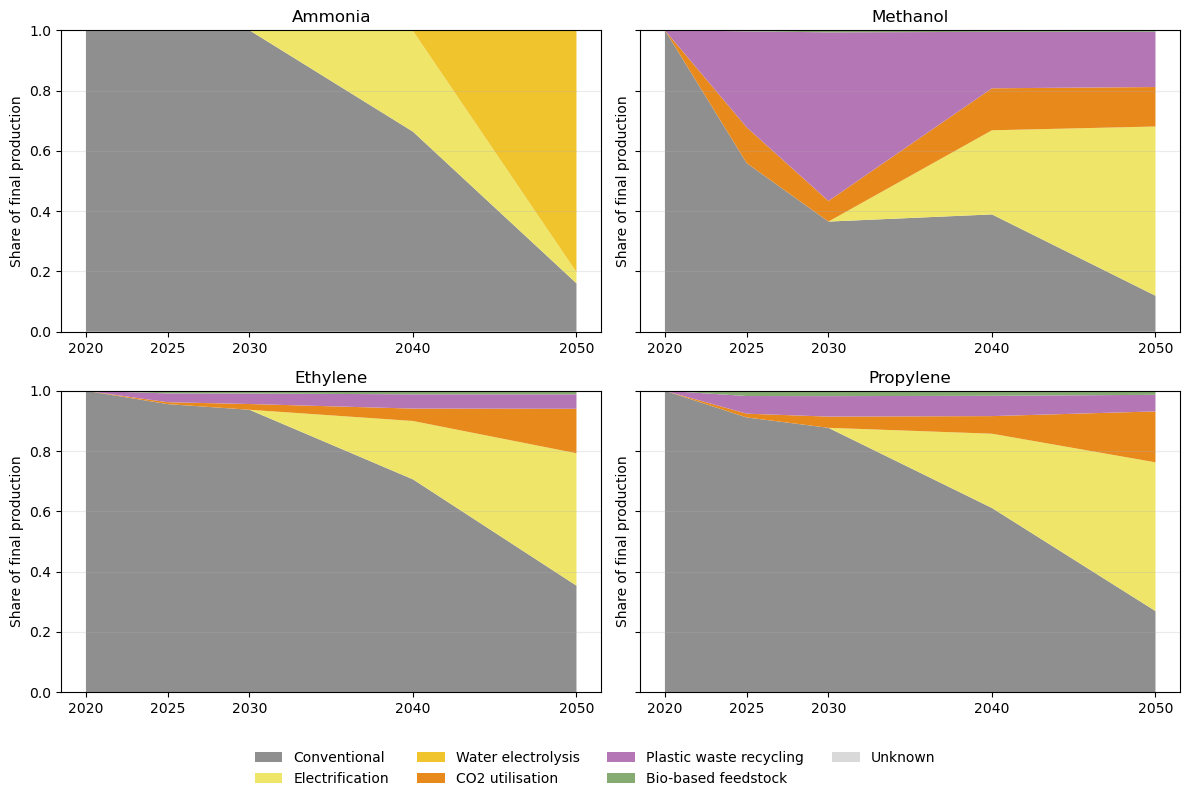

In [2]:

from __future__ import annotations

from pathlib import Path
from collections import defaultdict
import re
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


EPS = 1e-9

CLASS_ORDER = [
    "Conventional",
    "Electrification",
    "Water electrolysis",
    "CO2 utilisation",
    "Plastic waste recycling",
    "Bio-based feedstock",
    "Unknown",
]

CLASS_COLORS = {
    "Conventional": "#8f8f8f",
    "Electrification": "#efe669",
    "Water electrolysis": "#f0c42d",
    "CO2 utilisation": "#e8891c",
    "Bio-based feedstock": "#85aa72",
    "Plastic waste recycling": "#b576b5",
    "Unknown": "#d9d9d9",
}

# Mapping on base technology names, i.e. without "_existing".
TECH_CLASS = {
    # fossil/conventional
    "CrackerFurnace": "Conventional",
    "SteamReformer": "Conventional",

    # electrified routes
    "eCrackerFurnace": "Electrification",
    "eSMR_syngas": "Electrification",

    # hydrogen routes
    "PEMEC": "Water electrolysis",
    "SOEC": "Water electrolysis",
    # circular / bio / CO2 routes
    "rWGS": "CO2 utilisation",
    "Plastic2methanol": "Plastic waste recycling",
    "Biomass2methanol": "Bio-based feedstock",
}

TRANSPARENT_TECHS = {
    "HaberBosch",
    "MeOHsynthesis",
    "MethanolToOlefins",
    "OlefinSeparation",
    "WGS_syngas",
    "HBfeed_mixer",
    "feedgas_mixer",
    "naphtha_mixer",
    "CO2_mixer",
    "Storage_H2",
    "Storage_Battery",
    "H2_network_connection_in",
    "H2_network_connection_out",
}


def base_technology_name(technology: str) -> str:
    """
    Merge existing/new versions in a single technology name.
    """
    return re.sub(r"_existing$", "", technology)


def annualize_dataset(dataset: h5py.Dataset, factors: np.ndarray | None) -> float:
    """
    Convert a representative-time-series dataset into an annual quantity.
    """
    arr = np.asarray(dataset[()])

    if arr.ndim == 0:
        return float(arr)

    arr = arr.astype(float, copy=False)

    if factors is not None and arr.shape == factors.shape:
        return float(np.dot(arr, factors))

    if factors is not None and arr.ndim == 1 and len(arr) == len(factors):
        return float(np.dot(arr, factors))

    # Fallback for datasets that are not representative time series.
    return float(np.nansum(arr))


def infer_year_from_path_or_period(path: Path, period: str) -> int | str:
    """
    Infer the scenario/reference year associated with an H5 result file.

    Priority:
    1. a 4-digit year in the parent folders, starting from the closest parent;
       e.g. output/base_case_old/2030/optimization_results.h5 -> 2030
    2. a 4-digit year in the file stem;
    3. the internal H5 period as fallback.

    The internal H5 period is intentionally not used first, because in this
    workflow it can be a fixed dummy value such as "2022" for all files.
    """
    path = Path(path)

    for parent in path.parents:
        folder_name = parent.name
        if re.fullmatch(r"(19|20)\d{2}", folder_name):
            return int(folder_name)

    match = re.search(r"(19|20)\d{2}", path.stem)
    if match:
        return int(match.group(0))

    period_str = str(period)
    if re.fullmatch(r"\d{4}", period_str):
        return int(period_str)

    return period_str


def read_period_totals(h5_path: str | Path) -> dict[int | str, dict[str, dict[str, dict[str, float]]]]:
    """
    Read one H5 file and return:
        {year: {node: {base_technology: {carrier: annual_value}}}}
    """
    h5_path = Path(h5_path)
    out = {}

    with h5py.File(h5_path, "r") as h5:
        tech_root = h5["operation"]["technology_operation"]

        for period in tech_root.keys():
            year = infer_year_from_path_or_period(h5_path, period)

            factors = None
            if "k_means_specs" in h5 and period in h5["k_means_specs"]:
                if "factors" in h5["k_means_specs"][period]:
                    factors = np.asarray(h5["k_means_specs"][period]["factors"][()], dtype=float)

            period_totals = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))

            for node in tech_root[period].keys():
                node_group = tech_root[period][node]

                for technology in node_group.keys():
                    base_tech = base_technology_name(technology)
                    tech_group = node_group[technology]

                    for carrier in tech_group.keys():
                        value = annualize_dataset(tech_group[carrier], factors)
                        if abs(value) > EPS:
                            period_totals[node][base_tech][carrier] += value

            out[year] = period_totals

    return out


def read_period_data(h5_path: str | Path) -> dict[int | str, dict]:
    """
    Read one H5 file and return period totals plus H2 network flows:
        {
            year: {
                "period_totals": {node: {base_technology: {carrier: annual_value}}},
                "h2_network_edges": [ ... ],
            }
        }
    """
    h5_path = Path(h5_path)
    out = {}

    with h5py.File(h5_path, "r") as h5:
        tech_root = h5["operation"]["technology_operation"]

        for period in tech_root.keys():
            year = infer_year_from_path_or_period(h5_path, period)

            factors = None
            if "k_means_specs" in h5 and period in h5["k_means_specs"]:
                if "factors" in h5["k_means_specs"][period]:
                    factors = np.asarray(h5["k_means_specs"][period]["factors"][()], dtype=float)

            period_totals = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))
            nodes = list(tech_root[period].keys())

            for node in nodes:
                node_group = tech_root[period][node]

                for technology in node_group.keys():
                    base_tech = base_technology_name(technology)
                    tech_group = node_group[technology]

                    for carrier in tech_group.keys():
                        value = annualize_dataset(tech_group[carrier], factors)
                        if abs(value) > EPS:
                            period_totals[node][base_tech][carrier] += value

            h2_network_edges = read_h2_network_edges(h5, period, factors, nodes)

            out[year] = {
                "period_totals": period_totals,
                "h2_network_edges": h2_network_edges,
            }

    return out


def carrier_amount(node_totals: dict, technology: str, carrier: str) -> float:
    return float(node_totals.get(technology, {}).get(carrier, 0.0))


def sum_carrier(node_totals: dict, carrier: str, technologies: set[str] | None = None) -> float:
    value = 0.0
    for technology, carriers in node_totals.items():
        if technologies is not None and technology not in technologies:
            continue
        value += float(carriers.get(carrier, 0.0))
    return value


def normalize_distribution(distribution: dict[str, float]) -> dict[str, float]:
    clean = {k: max(0.0, float(v)) for k, v in distribution.items() if abs(v) > EPS}
    total = sum(clean.values())
    if total <= EPS:
        return {}
    return {k: v / total for k, v in clean.items()}


def add_amount(distribution: dict[str, float], amount: float, klass: str | None = None,
               shares: dict[str, float] | None = None) -> None:
    """
    Add amount to distribution, either directly to klass or proportionally to shares.
    """
    if amount <= EPS:
        return

    if shares:
        for k, s in shares.items():
            distribution[k] += amount * s
    elif klass is not None:
        distribution[klass] += amount
    else:
        distribution["Unknown"] += amount


def technology_class(technology: str) -> str | None:
    return TECH_CLASS.get(base_technology_name(technology))


def merge_distributions(*distributions: dict[str, float]) -> dict[str, float]:
    """
    Sum multiple class-amount distributions.
    """
    out = defaultdict(float)
    for distribution in distributions:
        for klass, value in distribution.items():
            out[klass] += float(value)
    return dict(out)


def parse_network_edge(edge_name: str, nodes: list[str]) -> tuple[str, str] | None:
    """
    Parse compact directed edge names such as BEL1NL4 into (BEL1, NL4).

    The function does not assume fixed node-name length. It searches all known
    node pairs and accepts the unique pair whose concatenation matches the edge
    name.
    """
    matches = []
    for source in nodes:
        for target in nodes:
            if source == target:
                continue
            if f"{source}{target}" == edge_name:
                matches.append((source, target))

    if len(matches) == 1:
        return matches[0]

    return None


def read_h2_network_edges(
    h5: h5py.File,
    period: str,
    factors: np.ndarray | None,
    nodes: list[str],
) -> list[dict[str, float | str]]:
    """
    Read annual directed H2 network flows.

    The code uses operation/networks/{period}/hydrogen*/{edge}/flow.
    Positive flow follows the edge name direction, e.g. BEL1NL4 = BEL1 -> NL4.
    Negative flow, if present, is interpreted as flow in the opposite direction.

    The amount received by the sink is flow - losses. The source-side flow is
    still kept because it is useful for diagnostics, but for attributing imported
    H2 to the receiving node we use the received amount.
    """
    edges = []

    if "operation" not in h5 or "networks" not in h5["operation"]:
        return edges
    if period not in h5["operation"]["networks"]:
        return edges

    networks_root = h5["operation"]["networks"][period]

    for network_name in networks_root.keys():
        if "hydrogen" not in network_name.lower():
            continue

        network_group = networks_root[network_name]
        for edge_name in network_group.keys():
            parsed = parse_network_edge(edge_name, nodes)
            if parsed is None:
                print(f"WARNING: could not parse H2 network edge '{edge_name}'. Skipping it.")
                continue

            source, target = parsed
            edge_group = network_group[edge_name]
            if "flow" not in edge_group:
                continue

            flow = annualize_dataset(edge_group["flow"], factors)
            losses = annualize_dataset(edge_group["losses"], factors) if "losses" in edge_group else 0.0

            if abs(flow) <= EPS:
                continue

            if flow >= 0:
                src, dst = source, target
                source_flow = flow
            else:
                src, dst = target, source
                source_flow = -flow

            losses = max(0.0, abs(losses))
            received_flow = max(0.0, source_flow - losses)

            edges.append({
                "network": network_name,
                "edge": edge_name,
                "source": src,
                "target": dst,
                "source_flow": float(source_flow),
                "losses": float(losses),
                "received_flow": float(received_flow),
            })

    return edges


def build_syngas_distribution(node_totals: dict) -> dict[str, float]:
    """
    Syngas class mix at node level.
    Used by MeOH synthesis and WGS.
    """
    dist = defaultdict(float)

    for technology, carriers in node_totals.items():
        amount = carriers.get("syngas_output", 0.0)
        if amount <= EPS:
            continue

        klass = technology_class(technology)

        if klass is not None:
            add_amount(dist, amount, klass=klass)
        elif technology not in TRANSPARENT_TECHS:
            add_amount(dist, amount, klass="Unknown")

    return dict(dist)


def build_local_hydrogen_distribution(node_totals: dict, syngas_shares: dict[str, float]) -> dict[str, float]:
    """
    Local hydrogen production mix at node level.

    This excludes H2 network connection technologies, because they do not produce
    hydrogen; they only convert local hydrogen into transported hydrogen, or
    transported hydrogen back into local hydrogen.
    """
    dist = defaultdict(float)

    for technology, carriers in node_totals.items():
        amount = carriers.get("hydrogen_output", 0.0)
        if amount <= EPS:
            continue

        if technology in {"Storage_H2", "H2_network_connection_in", "H2_network_connection_out"}:
            continue

        if technology == "WGS_syngas":
            add_amount(dist, amount, shares=syngas_shares)
            continue

        klass = technology_class(technology)

        if klass is not None:
            add_amount(dist, amount, klass=klass)
        elif technology not in TRANSPARENT_TECHS:
            add_amount(dist, amount, klass="Unknown")

    return dict(dist)


def calculate_local_hydrogen_distributions(period_totals: dict) -> dict[str, dict[str, float]]:
    """Calculate local H2 production class distributions for all nodes."""
    out = {}
    for node, node_totals in period_totals.items():
        syngas_dist = build_syngas_distribution(node_totals)
        syngas_shares = normalize_distribution(syngas_dist)
        out[node] = build_local_hydrogen_distribution(node_totals, syngas_shares)
    return out


def topological_node_order(nodes: list[str], edges: list[dict]) -> list[str] | None:
    """Return a topological order for the positive-flow H2 network, if acyclic."""
    outgoing = {node: [] for node in nodes}
    indegree = {node: 0 for node in nodes}

    for edge in edges:
        source = str(edge["source"])
        target = str(edge["target"])
        if source not in outgoing:
            outgoing[source] = []
            indegree.setdefault(source, 0)
        if target not in outgoing:
            outgoing[target] = []
            indegree.setdefault(target, 0)
        outgoing[source].append(target)
        indegree[target] += 1

    queue = [node for node in nodes if indegree.get(node, 0) == 0]
    order = []

    while queue:
        node = queue.pop(0)
        order.append(node)
        for target in outgoing.get(node, []):
            indegree[target] -= 1
            if indegree[target] == 0:
                queue.append(target)

    if len(order) != len(set(list(nodes) + list(indegree.keys()))):
        return None

    return order


def calculate_imported_hydrogen_distributions(
    period_totals: dict,
    h2_network_edges: list[dict] | None,
) -> dict[str, dict[str, float]]:
    """
    Attribute H2 imported from the network to the production class of the H2
    before entering the network.

    The method traces the transported-hydrogen carrier through the directed H2
    network. At each node, transported H2 is assumed to be perfectly mixed:
    local injections into the network and upstream inflows form a common pool;
    withdrawals via H2_network_connection_in and downstream outflows inherit the
    pool composition.
    """
    if not h2_network_edges:
        return {node: {} for node in period_totals.keys()}

    nodes = list(period_totals.keys())
    local_h2 = calculate_local_hydrogen_distributions(period_totals)

    # Local injections into the transported-H2 network.
    injected_by_node = {}
    for node, node_totals in period_totals.items():
        injected = sum_carrier(
            node_totals,
            "hydrogen_transported_output",
            technologies={"H2_network_connection_out"},
        )
        injected_by_node[node] = max(0.0, injected)

    # Withdrawals from the transported-H2 network back to local hydrogen.
    withdrawn_by_node = {}
    for node, node_totals in period_totals.items():
        withdrawn = sum_carrier(
            node_totals,
            "hydrogen_output",
            technologies={"H2_network_connection_in"},
        )
        withdrawn_by_node[node] = max(0.0, withdrawn)

    # Organize outgoing network edges.
    outgoing_edges = {node: [] for node in nodes}
    for edge in h2_network_edges:
        outgoing_edges.setdefault(str(edge["source"]), []).append(edge)

    order = topological_node_order(nodes, h2_network_edges)
    if order is None:
        # Cycles should not occur in an optimal unidirectional annual H2 flow
        # solution, but if they do, this fallback avoids crashing. It is less
        # rigorous than the acyclic tracing and should be investigated.
        print("WARNING: H2 network contains a directed cycle. Using file node order for tracing.")
        order = nodes

    transported_pool = {node: defaultdict(float) for node in nodes}
    imported_h2 = {node: defaultdict(float) for node in nodes}

    for node in order:
        # Add local injection to the transported-H2 pool.
        injected = injected_by_node.get(node, 0.0)
        if injected > EPS:
            local_shares = normalize_distribution(local_h2.get(node, {}))
            if local_shares:
                for klass, share in local_shares.items():
                    transported_pool[node][klass] += injected * share
            else:
                transported_pool[node]["Unknown"] += injected

        pool_shares = normalize_distribution(transported_pool[node])

        # Withdraw imported transported H2 into the local hydrogen carrier.
        withdrawn = withdrawn_by_node.get(node, 0.0)
        if withdrawn > EPS:
            if pool_shares:
                for klass, share in pool_shares.items():
                    imported_h2[node][klass] += withdrawn * share
            else:
                imported_h2[node]["Unknown"] += withdrawn

        # Send transported H2 further downstream. Losses reduce the received
        # amount, but do not change the class mix.
        for edge in outgoing_edges.get(node, []):
            target = str(edge["target"])
            received_flow = float(edge.get("received_flow", 0.0))
            if received_flow <= EPS:
                continue

            if pool_shares:
                for klass, share in pool_shares.items():
                    transported_pool[target][klass] += received_flow * share
            else:
                transported_pool[target]["Unknown"] += received_flow

    return {node: dict(dist) for node, dist in imported_h2.items()}


def build_methanol_production_distribution(node_totals: dict, syngas_shares: dict[str, float]) -> dict[str, float]:
    """
    Gross methanol production class mix at node level.
    Methanol synthesis inherits syngas classes; direct bio/plastic routes keep their own class.
    """
    dist = defaultdict(float)

    for technology, carriers in node_totals.items():
        amount = carriers.get("methanol_output", 0.0)
        if amount <= EPS:
            continue

        if technology == "MeOHsynthesis":
            add_amount(dist, amount, shares=syngas_shares)
            continue

        klass = technology_class(technology)

        if klass is not None:
            add_amount(dist, amount, klass=klass)
        elif technology not in TRANSPARENT_TECHS:
            add_amount(dist, amount, klass="Unknown")

    return dict(dist)


def build_olefins_distribution(node_totals: dict, methanol_shares: dict[str, float]) -> dict[str, float]:
    """
    Olefins class mix before olefin separation.
    MTO olefins inherit the methanol class mix if the model uses olefins_output there.
    """
    dist = defaultdict(float)

    for technology, carriers in node_totals.items():
        amount = carriers.get("olefins_output", 0.0)
        if amount <= EPS:
            continue

        if technology == "MethanolToOlefins":
            add_amount(dist, amount, shares=methanol_shares)
            continue

        klass = technology_class(technology)

        if klass is not None:
            add_amount(dist, amount, klass=klass)
        elif technology not in TRANSPARENT_TECHS:
            add_amount(dist, amount, klass="Unknown")

    return dict(dist)


def calculate_node_final_chemicals(
    node_totals: dict,
    imported_hydrogen_distribution: dict[str, float] | None = None,
) -> dict[str, dict[str, float]]:
    """
    Return annual final-chemical production by class for a single node:
        {
            "ammonia": {"Conventional": ..., ...},
            "methanol": {...},
            "ethylene": {...},
            "propylene": {...},
        }
    """
    result = {
        "ammonia": defaultdict(float),
        "methanol": defaultdict(float),
        "ethylene": defaultdict(float),
        "propylene": defaultdict(float),
    }

    syngas_dist = build_syngas_distribution(node_totals)
    syngas_shares = normalize_distribution(syngas_dist)

    local_hydrogen_dist = build_local_hydrogen_distribution(node_totals, syngas_shares)
    hydrogen_dist = merge_distributions(
        local_hydrogen_dist,
        imported_hydrogen_distribution or {},
    )
    hydrogen_shares = normalize_distribution(hydrogen_dist)

    methanol_prod_dist = build_methanol_production_distribution(node_totals, syngas_shares)
    methanol_prod_shares = normalize_distribution(methanol_prod_dist)
    gross_methanol = sum(methanol_prod_dist.values())

    # Methanol consumed by MTO is not counted as final methanol.
    mto_methanol_input = sum_carrier(node_totals, "methanol_input", technologies={"MethanolToOlefins"})
    final_methanol = gross_methanol - mto_methanol_input

    if final_methanol < -1e-6:
        print(
            f"WARNING: node has methanol_input to MTO larger than gross methanol production "
            f"({mto_methanol_input:.3f} > {gross_methanol:.3f}). "
            "Final methanol is clipped to zero."
        )

    final_methanol = max(0.0, final_methanol)
    add_amount(result["methanol"], final_methanol, shares=methanol_prod_shares)

    # Ammonia: Haber-Bosch is transparent; route is assigned from hydrogen origin.
    ammonia = sum_carrier(node_totals, "ammonia_output", technologies={"HaberBosch"})
    add_amount(result["ammonia"], ammonia, shares=hydrogen_shares)

    # Olefin separation inherits the class mix of the olefins pool.
    olefins_dist = build_olefins_distribution(node_totals, methanol_prod_shares)
    olefins_shares = normalize_distribution(olefins_dist)

    # Ethylene and propylene may come either directly from MTO or from OlefinSeparation.
    for final_carrier, chemical in [
        ("ethylene_output", "ethylene"),
        ("propylene_output", "propylene"),
    ]:
        for technology, carriers in node_totals.items():
            amount = carriers.get(final_carrier, 0.0)
            if amount <= EPS:
                continue

            if technology == "MethanolToOlefins":
                add_amount(result[chemical], amount, shares=methanol_prod_shares)
            elif technology == "OlefinSeparation":
                add_amount(result[chemical], amount, shares=olefins_shares)
            else:
                klass = technology_class(technology)
                add_amount(result[chemical], amount, klass=klass)

    return {chem: dict(dist) for chem, dist in result.items()}


def calculate_period_final_chemicals(
    period_totals: dict,
    h2_network_edges: list[dict] | None = None,
) -> dict[str, dict[str, float]]:
    """
    Aggregate class-resolved final-chemical production over all nodes.
    Node-level propagation is done before aggregation to avoid artificial cross-node mixing.
    """
    out = {
        "ammonia": defaultdict(float),
        "methanol": defaultdict(float),
        "ethylene": defaultdict(float),
        "propylene": defaultdict(float),
    }

    imported_h2_by_node = calculate_imported_hydrogen_distributions(period_totals, h2_network_edges)

    for node, node_totals in period_totals.items():
        node_result = calculate_node_final_chemicals(
            node_totals,
            imported_hydrogen_distribution=imported_h2_by_node.get(node, {}),
        )
        for chemical, dist in node_result.items():
            for klass, value in dist.items():
                out[chemical][klass] += value

    return {chem: dict(dist) for chem, dist in out.items()}


def analyze_h5_files(h5_files: list[str | Path]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Analyze one or more H5 files.

    Returns
    -------
    amounts_df:
        columns = year, chemical, class, amount
    shares_df:
        columns = year, chemical, class, amount, total, share
    """
    amount_rows = []

    for h5_file in h5_files:
        file_periods = read_period_data(h5_file)

        for year, data in file_periods.items():
            period_totals = data["period_totals"]
            h2_network_edges = data["h2_network_edges"]
            final_by_class = calculate_period_final_chemicals(period_totals, h2_network_edges)

            for chemical, dist in final_by_class.items():
                for klass in CLASS_ORDER:
                    amount_rows.append({
                        "year": year,
                        "chemical": chemical,
                        "class": klass,
                        "amount": float(dist.get(klass, 0.0)),
                    })

                # Preserve unexpected classes, if any.
                for klass, value in dist.items():
                    if klass not in CLASS_ORDER:
                        amount_rows.append({
                            "year": year,
                            "chemical": chemical,
                            "class": klass,
                            "amount": float(value),
                        })

    amounts_df = pd.DataFrame(amount_rows)

    totals = (
        amounts_df
        .groupby(["year", "chemical"], as_index=False)["amount"]
        .sum()
        .rename(columns={"amount": "total"})
    )

    shares_df = amounts_df.merge(totals, on=["year", "chemical"], how="left")
    shares_df["share"] = np.where(
        shares_df["total"] > EPS,
        shares_df["amount"] / shares_df["total"],
        np.nan,
    )

    return amounts_df, shares_df


def _sort_years(years):
    def key(y):
        try:
            return int(y)
        except Exception:
            return str(y)
    return sorted(years, key=key)


def plot_final_chemical_shares(
    shares_df: pd.DataFrame,
    output_path: str | Path = "final_chemical_pathway_shares.png",
    chemicals: tuple[str, ...] = ("ammonia", "methanol", "ethylene", "propylene"),
    class_order: list[str] = CLASS_ORDER,
    class_colors: dict[str, str] = CLASS_COLORS,
):
    """
    Create a 2x2 stacked-area plot of final-chemical production shares by class.
    If only one year is available, the function falls back to stacked bars.
    """
    output_path = Path(output_path)

    years = _sort_years(shares_df["year"].dropna().unique())
    x_numeric = np.array([int(y) if str(y).isdigit() else i for i, y in enumerate(years)])

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=True)
    axes = axes.ravel()

    for ax, chemical in zip(axes, chemicals):
        sub = shares_df[shares_df["chemical"] == chemical].copy()

        pivot = (
            sub
            .pivot_table(index="year", columns="class", values="share", aggfunc="sum")
            .reindex(index=years)
            .fillna(0.0)
        )

        # Keep only classes that are present or explicitly ordered.
        ordered_classes = [c for c in class_order if c in pivot.columns]
        ordered_classes += [c for c in pivot.columns if c not in ordered_classes]

        y_values = [pivot[c].values for c in ordered_classes]
        colors = [class_colors.get(c, None) for c in ordered_classes]

        if len(years) == 1:
            bottom = 0.0
            for c, y, color in zip(ordered_classes, y_values, colors):
                value = float(y[0])
                if value <= EPS:
                    continue
                ax.bar([0], [value], bottom=[bottom], label=c, color=color)
                bottom += value
            ax.set_xticks([0])
            ax.set_xticklabels([str(years[0])])
        else:
            ax.stackplot(x_numeric, y_values, labels=ordered_classes, colors=colors)
            ax.set_xticks(x_numeric)
            ax.set_xticklabels([str(y) for y in years])

        ax.set_title(chemical.capitalize())
        ax.set_ylim(0, 1)
        ax.set_ylabel("Share of final production")
        ax.grid(axis="y", alpha=0.25)

    # Shared legend, without duplicate labels.
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        for hi, li in zip(h, l):
            if li not in labels:
                handles.append(hi)
                labels.append(li)

    fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)
    fig.tight_layout(rect=[0, 0.08, 1, 1])
    # fig.savefig(output_path, dpi=300, bbox_inches="tight")
    return fig


if __name__ == "__main__":
    # Example 1: explicit list
    # h5_files = [
    #     r"output/base_case_10_dd/2020/optimization_results.h5",
    #     r"output/base_case_10_dd/2025/optimization_results.h5",
    #     r"output/base_case_10_dd/2030/optimization_results.h5",
    #     r"output/base_case_10_dd/2040/optimization_results.h5",
    #     r"output/base_case_10_dd/2050/optimization_results.h5",
    # ]

    # Example 2: alternatively, find all optimization_results.h5 files recursively.
    h5_files = sorted(Path("output/high_feedstock_availability_10_dd_2h").glob("*/optimization_results.h5"))

    amounts, shares = analyze_h5_files(h5_files)

    # amounts.to_csv("final_chemical_pathway_amounts.csv", index=False)
    # shares.to_csv("final_chemical_pathway_shares.csv", index=False)

    plot_final_chemical_shares(
        shares,
        output_path="final_chemical_pathway_shares.png",
    )

    print("Saved:")
    print("  final_chemical_pathway_amounts.csv")
    print("  final_chemical_pathway_shares.csv")
    print("  final_chemical_pathway_shares.png")


Costs for feedstocks

Saved:
  feedstock_spending_amounts.csv
  feedstock_spending_shares.csv
  feedstock_spending_shares.png


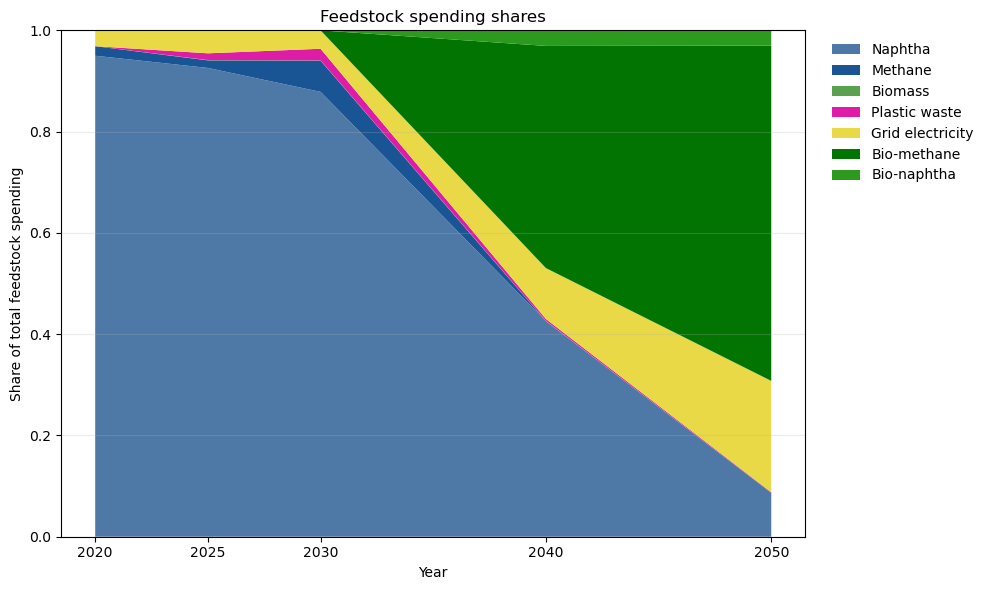

In [6]:
from __future__ import annotations

from pathlib import Path
import re
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EPS = 1e-9

# Optional preferred order / colors for common feedstocks.
CARRIER_ORDER = [
    "naphtha",
    "methane",
    "biomass",
    "MPW",
    "electricity_grid",
    "CO2",
    "hydrogen",
    "feedgas",
    "crackergas",
]

CARRIER_COLORS = {
    "naphtha": "#4e79a7",
    "methane": "#195494",
    "biomass": "#59a14f",
    "MPW": "#df1ca7",
    "electricity_grid": "#e9d947",
    "CO2": "#76b7b2",
    "hydrogen": "#edc948",
    "feedgas": "#9c755f",
    "crackergas": "#bab0ab",
    "naphtha_bio": "#2c9b1d",
    "methane_bio": "#027402",
}

LABELS = {
    "naphtha": "Naphtha",
    "methane": "Methane",
    "biomass": "Biomass",
    "MPW": "Plastic waste",
    "electricity_grid": "Grid electricity",
    "CO2": "CO2",
    "hydrogen": "Hydrogen",
    "feedgas": "Feedgas",
    "crackergas": "Crackergas",
    "naphtha_bio": "Bio-naphtha",
    "methane_bio": "Bio-methane",
}

# Carriers that are usually not meaningful as imported feedstocks for this plot.
DEFAULT_EXCLUDE = {
    "ammonia",
    "methanol",
    "ethylene",
    "propylene",
    "olefins",
    "cracking_byproducts",
    "hydrogen_transported",
    "electricity",
    "heat",
    "HBfeed",
}


def infer_year_from_path_or_period(path: str | Path, period: str) -> int | str:
    """
    Infer the scenario/reference year associated with an H5 result file.

    Priority:
    1. a 4-digit year in the parent folders, starting from the closest parent;
    2. a 4-digit year in the file stem;
    3. the internal H5 period as fallback.
    """
    path = Path(path)

    for parent in path.parents:
        folder_name = parent.name
        if re.fullmatch(r"(19|20)\d{2}", folder_name):
            return int(folder_name)

    match = re.search(r"(19|20)\d{2}", path.stem)
    if match:
        return int(match.group(0))

    period_str = str(period)
    if re.fullmatch(r"\d{4}", period_str):
        return int(period_str)

    return period_str


def weighted_sum(values: np.ndarray, factors: np.ndarray | None) -> float:
    arr = np.asarray(values, dtype=float)
    if arr.ndim == 0:
        return float(arr)
    if factors is not None and arr.shape == factors.shape:
        return float(np.dot(arr, factors))
    if factors is not None and arr.ndim == 1 and len(arr) == len(factors):
        return float(np.dot(arr, factors))
    return float(np.nansum(arr))


def annual_import_cost(import_values: np.ndarray, import_prices: np.ndarray, factors: np.ndarray | None) -> float:
    values = np.asarray(import_values, dtype=float)
    prices = np.asarray(import_prices, dtype=float)

    if values.ndim == 0 and prices.ndim == 0:
        return float(values * prices)

    prod = values * prices
    if factors is not None and prod.shape == factors.shape:
        return float(np.dot(prod, factors))
    if factors is not None and prod.ndim == 1 and len(prod) == len(factors):
        return float(np.dot(prod, factors))
    return float(np.nansum(prod))


def read_feedstock_spending(
    h5_path: str | Path,
    include_carriers: list[str] | tuple[str, ...] | None = None,
    exclude_carriers: set[str] | None = None,
) -> pd.DataFrame:
    """
    Return one row per (year, carrier) with annual imported amount and annual spending,
    summed over all nodes.
    """
    h5_path = Path(h5_path)
    rows: list[dict] = []
    exclude_carriers = set() if exclude_carriers is None else set(exclude_carriers)

    with h5py.File(h5_path, "r") as h5:
        eb_root = h5["operation"]["energy_balance"]

        for period in eb_root.keys():
            year = infer_year_from_path_or_period(h5_path, period)

            factors = None
            if "k_means_specs" in h5 and period in h5["k_means_specs"]:
                if "factors" in h5["k_means_specs"][period]:
                    factors = np.asarray(h5["k_means_specs"][period]["factors"][()], dtype=float)

            carrier_totals: dict[str, dict[str, float]] = {}

            for node in eb_root[period].keys():
                for carrier in eb_root[period][node].keys():
                    if include_carriers is not None and carrier not in include_carriers:
                        continue
                    if carrier in exclude_carriers:
                        continue

                    group = eb_root[period][node][carrier]
                    if "import" not in group or "import_price" not in group:
                        continue

                    imported_amount = weighted_sum(group["import"][()], factors)
                    spending = annual_import_cost(group["import"][()], group["import_price"][()], factors)

                    if abs(imported_amount) <= EPS and abs(spending) <= EPS:
                        continue

                    if carrier not in carrier_totals:
                        carrier_totals[carrier] = {"import_amount": 0.0, "spending": 0.0}
                    carrier_totals[carrier]["import_amount"] += imported_amount
                    carrier_totals[carrier]["spending"] += spending

            for carrier, totals in carrier_totals.items():
                rows.append(
                    {
                        "year": year,
                        "carrier": carrier,
                        "import_amount": float(totals["import_amount"]),
                        "spending": float(totals["spending"]),
                    }
                )

    return pd.DataFrame(rows)


def analyze_h5_files(
    h5_files: list[str | Path],
    include_carriers: list[str] | tuple[str, ...] | None = None,
    exclude_carriers: set[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns
    -------
    amounts_df:
        columns = year, carrier, import_amount, spending
    shares_df:
        columns = year, carrier, import_amount, spending, total_spending, share
    """
    frames = []
    for h5_file in h5_files:
        df = read_feedstock_spending(
            h5_file,
            include_carriers=include_carriers,
            exclude_carriers=exclude_carriers,
        )
        if not df.empty:
            frames.append(df)

    if frames:
        amounts_df = pd.concat(frames, ignore_index=True)
    else:
        amounts_df = pd.DataFrame(columns=["year", "carrier", "import_amount", "spending"])

    if amounts_df.empty:
        shares_df = amounts_df.copy()
        shares_df["total_spending"] = []
        shares_df["share"] = []
        return amounts_df, shares_df

    amounts_df = (
        amounts_df.groupby(["year", "carrier"], as_index=False)[["import_amount", "spending"]]
        .sum()
    )

    totals = (
        amounts_df.groupby("year", as_index=False)["spending"]
        .sum()
        .rename(columns={"spending": "total_spending"})
    )

    shares_df = amounts_df.merge(totals, on="year", how="left")
    shares_df["share"] = np.where(
        shares_df["total_spending"].abs() > EPS,
        shares_df["spending"] / shares_df["total_spending"],
        np.nan,
    )

    return amounts_df, shares_df


def _sort_years(years):
    def key(y):
        try:
            return int(y)
        except Exception:
            return str(y)
    return sorted(years, key=key)


def plot_feedstock_spending_shares(
    shares_df: pd.DataFrame,
    output_path: str | Path = "feedstock_spending_shares.png",
    carrier_order: list[str] = CARRIER_ORDER,
    carrier_colors: dict[str, str] = CARRIER_COLORS,
    label_map: dict[str, str] = LABELS,
):
    """
    Plot annual spending shares by feedstock.
    Falls back to stacked bars when only one year is available.
    """
    output_path = Path(output_path)

    if shares_df.empty:
        raise ValueError("shares_df is empty: no spending data found to plot.")

    years = _sort_years(shares_df["year"].dropna().unique())
    x_numeric = np.array([int(y) if str(y).isdigit() else i for i, y in enumerate(years)])

    pivot = (
        shares_df.pivot_table(index="year", columns="carrier", values="share", aggfunc="sum")
        .reindex(index=years)
        .fillna(0.0)
    )

    ordered_carriers = [c for c in carrier_order if c in pivot.columns]
    ordered_carriers += [c for c in pivot.columns if c not in ordered_carriers]

    y_values = [pivot[c].values for c in ordered_carriers]
    colors = [carrier_colors.get(c, None) for c in ordered_carriers]
    labels = [label_map.get(c, c) for c in ordered_carriers]

    fig, ax = plt.subplots(figsize=(10, 6))

    if len(years) == 1:
        bottom = 0.0
        for lab, y, color in zip(labels, y_values, colors):
            value = float(y[0])
            if value <= EPS:
                continue
            ax.bar([0], [value], bottom=[bottom], label=lab, color=color)
            bottom += value
        ax.set_xticks([0])
        ax.set_xticklabels([str(years[0])])
    else:
        ax.stackplot(x_numeric, y_values, labels=labels, colors=colors)
        ax.set_xticks(x_numeric)
        ax.set_xticklabels([str(y) for y in years])

    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of total feedstock spending")
    ax.set_xlabel("Year")
    ax.set_title("Feedstock spending shares")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

    fig.tight_layout()
    # fig.savefig(output_path, dpi=300, bbox_inches="tight")
    return fig


if __name__ == "__main__":
    # Example 1: explicit list. Year is inferred from the parent folder name when available.
    h5_files = [
        r"output/base_case_5_dd/2020/optimization_results.h5",
        r"output/base_case_5_dd/2025/optimization_results.h5",
        r"output/base_case_5_dd/2030/optimization_results.h5",
        r"output/base_case_5_dd/2040/optimization_results.h5",
        r"output/base_case_5_dd/2050/optimization_results.h5"
    ]

    # Example 2: recursive discovery.
    # h5_files = sorted(Path("output\base_case_5_dd").glob("**/optimization_results.h5"))

    # If you want explicit control, set include_carriers to the feedstocks you care about.
    include_carriers = ["naphtha", "methane", "biomass", "MPW", "electricity_grid", "CO2", "hydrogen", "naphtha_bio", "methane_bio"]

    amounts, shares = analyze_h5_files(
        h5_files,
        include_carriers=include_carriers,
        exclude_carriers=DEFAULT_EXCLUDE,
    )

    # amounts.to_csv("feedstock_spending_amounts.csv", index=False)
    # shares.to_csv("feedstock_spending_shares.csv", index=False)

    plot_feedstock_spending_shares(
        shares,
        output_path="feedstock_spending_shares.png",
    )

    print("Saved:")
    print("  feedstock_spending_amounts.csv")
    print("  feedstock_spending_shares.csv")
    print("  feedstock_spending_shares.png")


Saved:
 - co2_transition_metrics.csv
 - co2_balance_area.png
 - feedstock_co2_potential_area.png
 - co2_transition_dashboard.png


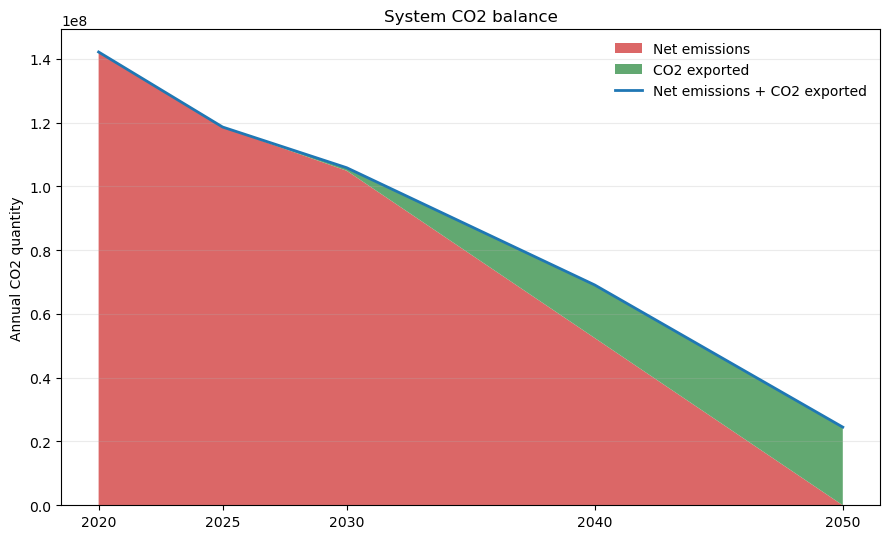

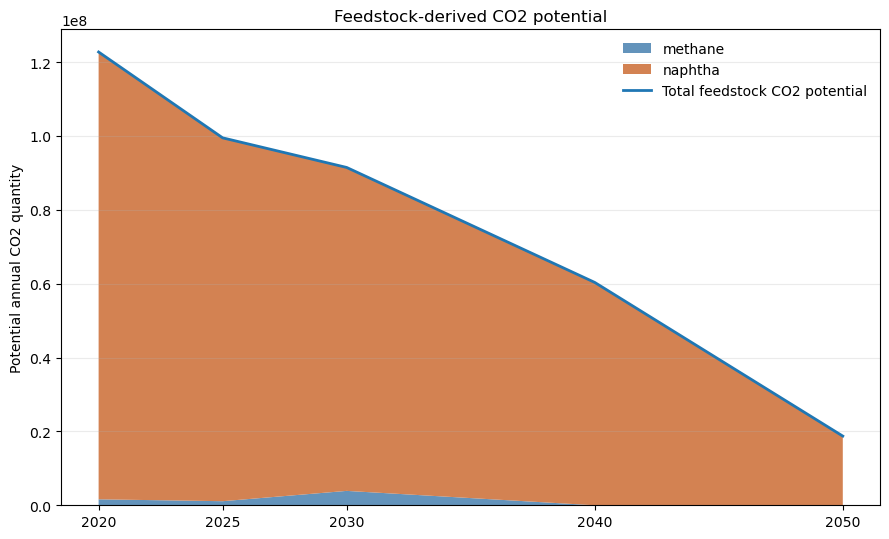

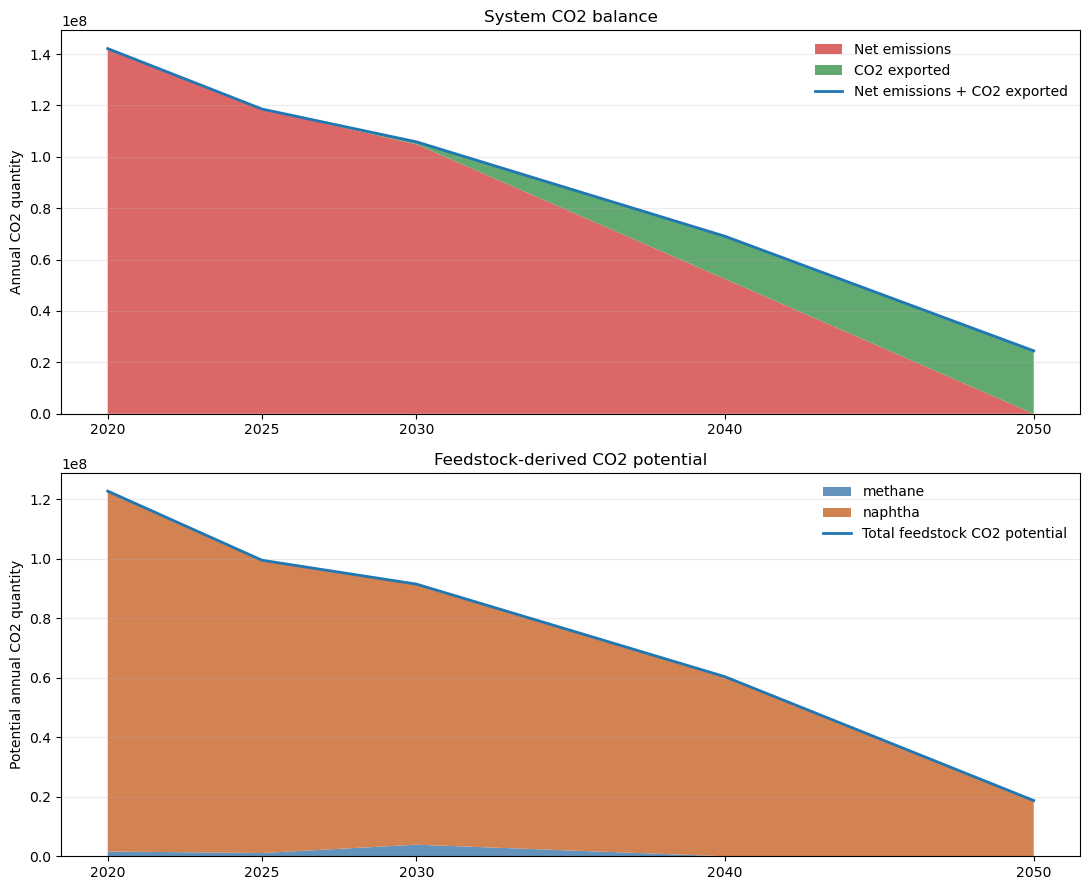

In [8]:
from __future__ import annotations

from pathlib import Path
import re
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EPS = 1e-9

# -----------------------------------------------------------------------------
# User-editable settings
# -----------------------------------------------------------------------------
# Emission factors to convert imported feedstocks into a potential CO2 quantity.
# Units must be consistent with the units used in the H5 energy_balance import.
# Example: if imports are in t_feedstock/y, factors can be tCO2/t_feedstock.
FEEDSTOCK_EMISSION_FACTORS = {
    "methane": 2.78,
    "naphtha": 3.23,
    "feedgas": 2.78,
    "crackergas": 2.78,
    "methane_bio": 0.0,
    "naphtha_bio": 0.0,
    "biomass": 0.0,
    "MPW": 0.0,
}

FEEDSTOCK_ORDER = list(FEEDSTOCK_EMISSION_FACTORS.keys())
FEEDSTOCK_COLORS = {
    "methane": "#5b8db8",
    "naphtha": "#d17b49",
    "feedgas": "#8f8f8f",
    "crackergas": "#b59b57",
    "methane_bio": "#7fad6c",
    "naphtha_bio": "#95c17d",
    "biomass": "#6ba36d",
    "MPW": "#9a7bb0",
}

CO2_STACK_COLORS = {
    "net_emissions": "#d95f5f",
    "co2_exported": "#5aa469",
}


# -----------------------------------------------------------------------------
# Utility functions
# -----------------------------------------------------------------------------

def annualize_dataset(dataset: h5py.Dataset, factors: np.ndarray | None) -> float:
    arr = np.asarray(dataset[()])

    if arr.ndim == 0:
        return float(arr)

    arr = arr.astype(float, copy=False)

    if factors is not None and arr.shape == factors.shape:
        return float(np.dot(arr, factors))

    if factors is not None and arr.ndim == 1 and len(arr) == len(factors):
        return float(np.dot(arr, factors))

    return float(np.nansum(arr))


def infer_year_from_path_or_period(path: Path, period: str) -> int | str:
    """
    Infer the scenario/reference year associated with an H5 result file.

    Priority:
    1. a 4-digit year in the parent folders, starting from the closest parent;
       e.g. output/2030/optimization_results.h5 -> 2030
    2. a 4-digit year in the file stem
    3. the internal H5 period as fallback
    """
    path = Path(path)

    for parent in path.parents:
        folder_name = parent.name
        if re.fullmatch(r"(19|20)\d{2}", folder_name):
            return int(folder_name)

    match = re.search(r"(19|20)\d{2}", path.stem)
    if match:
        return int(match.group(0))

    period_str = str(period)
    if re.fullmatch(r"\d{4}", period_str):
        return int(period_str)

    return period_str


def sort_years(values):
    def key(v):
        try:
            return int(v)
        except Exception:
            return str(v)
    return sorted(values, key=key)

def _to_scalar(x):
    """HDF5 dataset -> python scalar, decodes bytes."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    return x


# -----------------------------------------------------------------------------
# Core extraction
# -----------------------------------------------------------------------------

def extract_period_metrics(h5_path: str | Path) -> list[dict]:
    h5_path = Path(h5_path)
    rows = []

    with h5py.File(h5_path, "r") as h5:
        tech_root = h5["operation"]["technology_operation"]
        eb_root = h5["operation"]["energy_balance"]

        for period in tech_root.keys():
            year = infer_year_from_path_or_period(h5_path, period)

            factors = None
            if "k_means_specs" in h5 and period in h5["k_means_specs"]:
                if "factors" in h5["k_means_specs"][period]:
                    factors = np.asarray(h5["k_means_specs"][period]["factors"][()], dtype=float)

            # 1) Net emissions from technology_operation
            # emissions_pos = 0.0
            # emissions_neg = 0.0
            # for node in tech_root[period].keys():
            #     for technology in tech_root[period][node].keys():
            #         tech_group = tech_root[period][node][technology]
            #         if "emissions_pos" in tech_group:
            #             emissions_pos += annualize_dataset(tech_group["emissions_pos"], factors)
            #         if "emissions_neg" in tech_group:
            #             emissions_neg += annualize_dataset(tech_group["emissions_neg"], factors)

            emissions_pos = float(_to_scalar(h5["summary"]["emissions_pos"]))
            emissions_neg = float(_to_scalar(h5["summary"]["emissions_neg"]))
            net_emissions = float(_to_scalar(h5['summary']['emissions_net']))

            # 2) CO2 exported outside the system boundary from energy_balance
            co2_export = 0.0
            co2captured_export = 0.0
            for node in eb_root[period].keys():
                node_group = eb_root[period][node]

                if "CO2" in node_group and "export" in node_group["CO2"]:
                    co2_export += annualize_dataset(node_group["CO2"]["export"], factors)
                if "CO2captured" in node_group and "export" in node_group["CO2captured"]:
                    co2captured_export += annualize_dataset(node_group["CO2captured"]["export"], factors)

            total_exported = co2_export + co2captured_export

            # 3) Fossil-feedstock carbon potential from energy_balance imports
            feedstock_imports = {}
            feedstock_co2_potential = {}
            for carrier, ef in FEEDSTOCK_EMISSION_FACTORS.items():
                imported = 0.0
                for node in eb_root[period].keys():
                    node_group = eb_root[period][node]
                    if carrier in node_group and "import" in node_group[carrier]:
                        imported += annualize_dataset(node_group[carrier]["import"], factors)
                feedstock_imports[carrier] = imported
                feedstock_co2_potential[carrier] = imported * float(ef)

            row = {
                "file": str(h5_path),
                "year": year,
                "emissions_pos": emissions_pos,
                "emissions_neg": emissions_neg,
                "net_emissions": net_emissions,
                "co2_export": co2_export,
                "co2captured_export": co2captured_export,
                "co2_exported": total_exported,
                "gross_co2_accounted": net_emissions + total_exported,
            }
            for carrier, value in feedstock_imports.items():
                row[f"{carrier}_import"] = value
            for carrier, value in feedstock_co2_potential.items():
                row[f"{carrier}_co2_potential"] = value
            row["feedstock_co2_potential_total"] = sum(feedstock_co2_potential.values())
            rows.append(row)

    return rows


def analyze_h5_files(h5_files: list[str | Path]) -> pd.DataFrame:
    rows = []
    for h5_file in h5_files:
        rows.extend(extract_period_metrics(h5_file))
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values("year").reset_index(drop=True)
    return df


# -----------------------------------------------------------------------------
# Plotting
# -----------------------------------------------------------------------------

def _x_positions(years):
    if all(str(y).isdigit() for y in years):
        return np.array([int(y) for y in years], dtype=float)
    return np.arange(len(years), dtype=float)


def plot_co2_balance(df: pd.DataFrame, output_path: str | Path = "co2_balance_area.png"):
    output_path = Path(output_path)
    years = sort_years(df["year"].tolist())
    sub = df.set_index("year").reindex(years)
    x = _x_positions(years)

    series_names = ["net_emissions", "co2_exported"]
    labels = ["Net emissions", "CO2 exported"]
    colors = [CO2_STACK_COLORS["net_emissions"], CO2_STACK_COLORS["co2_exported"]]
    y_values = [sub[name].fillna(0.0).values for name in series_names]
    total = sub["gross_co2_accounted"].fillna(0.0).values

    fig = plt.figure(figsize=(9, 5.5))
    ax = fig.add_subplot(111)

    if len(years) == 1:
        bottom = 0.0
        for label, y, color in zip(labels, y_values, colors):
            value = float(y[0])
            if abs(value) <= EPS:
                continue
            ax.bar([0], [value], bottom=[bottom], label=label, color=color)
            bottom += value
        ax.plot([0], total, marker="o", linewidth=2, label="Net emissions + CO2 exported")
        ax.set_xticks([0])
        ax.set_xticklabels([str(years[0])])
    else:
        ax.stackplot(x, y_values, labels=labels, colors=colors, alpha=0.95)
        ax.plot(x, total, linewidth=2, label="Net emissions + CO2 exported")
        ax.set_xticks(x)
        ax.set_xticklabels([str(y) for y in years])

    ax.set_title("System CO2 balance")
    ax.set_ylabel("Annual CO2 quantity")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    # fig.savefig(output_path, dpi=300, bbox_inches="tight")
    return fig


def plot_feedstock_potential(df: pd.DataFrame, output_path: str | Path = "feedstock_co2_potential_area.png"):
    output_path = Path(output_path)
    years = sort_years(df["year"].tolist())
    sub = df.set_index("year").reindex(years)
    x = _x_positions(years)

    carriers = []
    y_values = []
    colors = []
    for carrier in FEEDSTOCK_ORDER:
        col = f"{carrier}_co2_potential"
        if col in sub.columns:
            values = sub[col].fillna(0.0).values
            if np.any(np.abs(values) > EPS):
                carriers.append(carrier)
                y_values.append(values)
                colors.append(FEEDSTOCK_COLORS.get(carrier, None))

    total = sub["feedstock_co2_potential_total"].fillna(0.0).values

    fig = plt.figure(figsize=(9, 5.5))
    ax = fig.add_subplot(111)

    if len(years) == 1:
        bottom = 0.0
        for carrier, y, color in zip(carriers, y_values, colors):
            value = float(y[0])
            if abs(value) <= EPS:
                continue
            ax.bar([0], [value], bottom=[bottom], label=carrier, color=color)
            bottom += value
        ax.plot([0], total, marker="o", linewidth=2, label="Total feedstock CO2 potential")
        ax.set_xticks([0])
        ax.set_xticklabels([str(years[0])])
    else:
        ax.stackplot(x, y_values, labels=carriers, colors=colors, alpha=0.95)
        ax.plot(x, total, linewidth=2, label="Total feedstock CO2 potential")
        ax.set_xticks(x)
        ax.set_xticklabels([str(y) for y in years])

    ax.set_title("Feedstock-derived CO2 potential")
    ax.set_ylabel("Potential annual CO2 quantity")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    # fig.savefig(output_path, dpi=300, bbox_inches="tight")
    return fig


def plot_combined_dashboard(
    df: pd.DataFrame,
    output_path: str | Path = "co2_transition_dashboard.png",
):
    output_path = Path(output_path)
    years = sort_years(df["year"].tolist())
    sub = df.set_index("year").reindex(years)
    x = _x_positions(years)

    fig = plt.figure(figsize=(11, 9))

    # Top subplot: CO2 balance
    ax1 = fig.add_subplot(211)
    co2_series = [sub["net_emissions"].fillna(0.0).values, sub["co2_exported"].fillna(0.0).values]
    co2_labels = ["Net emissions", "CO2 exported"]
    co2_colors = [CO2_STACK_COLORS["net_emissions"], CO2_STACK_COLORS["co2_exported"]]
    co2_total = sub["gross_co2_accounted"].fillna(0.0).values

    if len(years) == 1:
        bottom = 0.0
        for label, y, color in zip(co2_labels, co2_series, co2_colors):
            value = float(y[0])
            if abs(value) <= EPS:
                continue
            ax1.bar([0], [value], bottom=[bottom], label=label, color=color)
            bottom += value
        ax1.plot([0], co2_total, marker="o", linewidth=2, label="Net emissions + CO2 exported")
        ax1.set_xticks([0])
        ax1.set_xticklabels([str(years[0])])
    else:
        ax1.stackplot(x, co2_series, labels=co2_labels, colors=co2_colors, alpha=0.95)
        ax1.plot(x, co2_total, linewidth=2, label="Net emissions + CO2 exported")
        ax1.set_xticks(x)
        ax1.set_xticklabels([str(y) for y in years])
    ax1.set_title("System CO2 balance")
    ax1.set_ylabel("Annual CO2 quantity")
    ax1.grid(axis="y", alpha=0.25)
    ax1.legend(frameon=False)

    # Bottom subplot: feedstock carbon potential
    ax2 = fig.add_subplot(212)
    fs_labels = []
    fs_series = []
    fs_colors = []
    for carrier in FEEDSTOCK_ORDER:
        col = f"{carrier}_co2_potential"
        if col in sub.columns:
            values = sub[col].fillna(0.0).values
            if np.any(np.abs(values) > EPS):
                fs_labels.append(carrier)
                fs_series.append(values)
                fs_colors.append(FEEDSTOCK_COLORS.get(carrier, None))
    fs_total = sub["feedstock_co2_potential_total"].fillna(0.0).values

    if len(years) == 1:
        bottom = 0.0
        for label, y, color in zip(fs_labels, fs_series, fs_colors):
            value = float(y[0])
            if abs(value) <= EPS:
                continue
            ax2.bar([0], [value], bottom=[bottom], label=label, color=color)
            bottom += value
        ax2.plot([0], fs_total, marker="o", linewidth=2, label="Total feedstock CO2 potential")
        ax2.set_xticks([0])
        ax2.set_xticklabels([str(years[0])])
    else:
        ax2.stackplot(x, fs_series, labels=fs_labels, colors=fs_colors, alpha=0.95)
        ax2.plot(x, fs_total, linewidth=2, label="Total feedstock CO2 potential")
        ax2.set_xticks(x)
        ax2.set_xticklabels([str(y) for y in years])
    ax2.set_title("Feedstock-derived CO2 potential")
    ax2.set_ylabel("Potential annual CO2 quantity")
    ax2.grid(axis="y", alpha=0.25)
    ax2.legend(frameon=False)

    fig.tight_layout()
    # fig.savefig(output_path, dpi=300, bbox_inches="tight")
    return fig


if __name__ == "__main__":
    # Example input list. The year is inferred from the parent folder.
    h5_files = [
        r"output/base_case_5_dd/2020/optimization_results.h5",
        r"output/base_case_5_dd/2025/optimization_results.h5",
        r"output/base_case_5_dd/2030/optimization_results.h5",
        r"output/base_case_5_dd/2040/optimization_results.h5",
        r"output/base_case_5_dd/2050/optimization_results.h5",
    ]

    # Keep only files that actually exist so the example block does not fail.
    h5_files = [Path(p) for p in h5_files if Path(p).exists()]

    if not h5_files:
        print("No H5 files found. Update 'h5_files' in the __main__ block.")
        raise SystemExit(0)

    metrics_df = analyze_h5_files(h5_files)
    # metrics_df.to_csv("co2_transition_metrics.csv", index=False)

    plot_co2_balance(metrics_df, "co2_balance_area.png")
    plot_feedstock_potential(metrics_df, "feedstock_co2_potential_area.png")
    plot_combined_dashboard(metrics_df, "co2_transition_dashboard.png")

    print("Saved:")
    print(" - co2_transition_metrics.csv")
    print(" - co2_balance_area.png")
    print(" - feedstock_co2_potential_area.png")
    print(" - co2_transition_dashboard.png")
